# Transformer-LSTM Credit Rating Baseline

Notebook su dung **Transformer-LSTM thuan** de du bao credit rating theo row-level protocol.

## Contract chinh
- Doc input tu Kaggle/local split `train.csv`, `val.csv`, `test.csv`.
- Giu row-level `row_id` de doi chieu voi `test.csv` va cac artifact downstream.
- Kien truc chi gom Transformer temporal block, LSTM mot chieu, entity embeddings va classification head.
- Khong them bien the kien truc phu hoac huan luyen nhieu thanh vien trong notebook nay.
- Luu metrics, probability va explainability artifacts vao `/kaggle/working/credit_rating_artifacts` hoac fallback local.


# Transformer-LSTM Credit Rating

Notebook nay giu workflow Transformer-LSTM thuan co the chay tren Kaggle va local.

- Nguon du lieu mac dinh: `/kaggle/input/credit-rating-dataset/test/{train,val,test}.csv` tren Kaggle, fallback `data/processed/test/` khi chay local.
- Dau ra mac dinh: `/kaggle/working/credit_rating_artifacts` tren Kaggle, fallback `artifacts/TLSTM/` khi chay local.
- Protocol danh gia chinh: row-level `test.csv`, khong tron train/val/test trong qua trinh fit scaler, encoder, sampler, hoac threshold calibration.


## Table of Contents

1. Environment & Paths (Cell 2)
2. Imports, Seed, Device Setup (Cell 3)
3. Load Dataset (Cell 4)
4. Exploratory Data Analysis (Cell 5)
5. Windowing & DataLoader (Cell 6)
6. Model Definition (Cell 7)
7. Training Loop (Cell 8)
8. Evaluation (Cell 9)
9. Visualization (Cell 10)
10. SHAP Interpretation (Cell 11)
11. Summary


## 1. Environment and Dependency Setup

Khối này thiết lập môi trường chạy (Kaggle/local), import thư viện, random seed  và  cấu hình thiết bị.


In [1]:
import os
import platform
import sys
from pathlib import Path

def detect_kaggle_runtime() -> bool:
    """Detect Kaggle robustly; Windows may contain a /kaggle-like path locally."""
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()

IN_KAGGLE = detect_kaggle_runtime()

def find_project_root(start: Path) -> Path:
    """Find repository root containing data/ and src/ when running locally."""
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(CURRENT_DIR)
WORKING_DIR = PROJECT_ROOT
ARTIFACT_DIR = WORKING_DIR / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Python:', platform.python_version())
print('Running on Kaggle:', IN_KAGGLE)
print('Current directory:', CURRENT_DIR)
print('Project root:', PROJECT_ROOT)
print('Artifact directory:', ARTIFACT_DIR.resolve())

Python: 3.12.12
Running on Kaggle: True
Current directory: /kaggle/working
Project root: /kaggle/working
Artifact directory: /kaggle/working/credit_rating_artifacts


In [2]:
import random
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, roc_curve, auc,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder, label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def probe_cuda_runtime_for_lstm():
    """Check whether CUDA kernels required by LSTM are actually runnable."""
    if not torch.cuda.is_available():
        return False, 'torch.cuda.is_available() == False'

    try:
        # Trigger CUDA context + basic matmul kernel.
        probe_a = torch.randn(2, 2, device='cuda')
        probe_b = torch.randn(2, 2, device='cuda')
        _ = probe_a @ probe_b

        # Trigger cuDNN/cuBLAS path used by nn.LSTM.
        probe_lstm = nn.LSTM(input_size=4, hidden_size=4, batch_first=True).to('cuda')
        probe_x = torch.randn(2, 3, 4, device='cuda')
        with torch.no_grad():
            _ = probe_lstm(probe_x)

        torch.cuda.synchronize()
        del probe_a, probe_b, probe_lstm, probe_x
        return True, 'CUDA runtime probe passed'
    except Exception as e:
        return False, f'{type(e).__name__}: {e}'

CUDA_RUNTIME_OK, CUDA_RUNTIME_NOTE = probe_cuda_runtime_for_lstm()
if not CUDA_RUNTIME_OK and torch.cuda.is_available():
    warnings.warn(
        'CUDA is visible but not compatible with current PyTorch/CUDA kernels. '
        f'Falling back to CPU. Details: {CUDA_RUNTIME_NOTE}'
    )

device = torch.device('cuda' if CUDA_RUNTIME_OK else 'cpu')
USE_CUDA = device.type == 'cuda'
if USE_CUDA:
    torch.cuda.manual_seed_all(SEED)

# Training reproducibility knobs for more stable runs across executions.
DETERMINISTIC_TRAINING = True
if USE_CUDA:
    if DETERMINISTIC_TRAINING:
        os.environ['PYTHONHASHSEED'] = str(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

print('Using device:', device)
print('Deterministic training:', DETERMINISTIC_TRAINING)
print('CUDA runtime probe:', CUDA_RUNTIME_NOTE)

Using device: cpu
Deterministic training: True
CUDA runtime probe: AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



## 2. Data Loading and Basic Inspection

Tải dữ liệu nguồn, kiểm tra cấu trúc bảng  và  xác nhận schema đầu vào trước khi huấn luyện.


In [3]:
def resolve_split_path(default_path, local_fallbacks=None):
    """Resolve Kaggle path first, then local paths relative to PROJECT_ROOT."""
    candidates = [Path(default_path)]
    if local_fallbacks:
        for p in local_fallbacks:
            p_obj = Path(p)
            if p_obj.is_absolute():
                candidates.append(p_obj)
            else:
                candidates.append(PROJECT_ROOT / p_obj)
                candidates.append(p_obj)

    seen = set()
    ordered_candidates = []
    for c in candidates:
        c_norm = str(c.resolve()) if c.exists() else str(c)
        if c_norm not in seen:
            seen.add(c_norm)
            ordered_candidates.append(c)

    for p in ordered_candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f'Cannot find data file. Tried: {[str(c) for c in ordered_candidates]}'
    )

TRAIN_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/train.csv',
    local_fallbacks=[
        'data/processed/test/train.csv',
        'data/processed/train_augmented_timegan.csv',
        'archive/ctgan/splits/train_augmented_timegan.csv',
        'archive/ctgan/splits/train_augmented_ctgan.csv',
    ],
)
VAL_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/val.csv',
    local_fallbacks=[
        'data/processed/test/val.csv',
        'data/processed/val.csv',
        'archive/ctgan/splits/val.csv',
        'data/processed/ctgan/splits/val.csv',
    ],
)
TEST_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/test.csv',
    local_fallbacks=[
        'data/processed/test/test.csv',
        'data/processed/test.csv',
        'archive/ctgan/splits/test.csv',
        'data/processed/ctgan/splits/test.csv',
    ],
)

# AGENT_FIX [P1]: Disable ticker disjoint enforcement.
# TimeGAN uses walk-forward date split — same ticker in train (old) and val/test (recent) is valid.
# Removing shared tickers drops most of val/test and makes evaluation non-representative.
ENFORCE_TICKER_DISJOINT = False

train_df = pd.read_csv(TRAIN_PATH, encoding='utf-8')
val_df = pd.read_csv(VAL_PATH, encoding='utf-8')
test_df = pd.read_csv(TEST_PATH, encoding='utf-8')

def ticker_set(frame):
    return set(frame['ticker'].astype(str).unique())

train_tickers_raw = ticker_set(train_df)
val_tickers_raw = ticker_set(val_df)
test_tickers_raw = ticker_set(test_df)

print('Ticker overlaps before optional disjoint filter:')
print(f"trainÄ‚Â¢Ă‹â€ Ă‚Â©val:  {len(train_tickers_raw & val_tickers_raw)}")
print(f"trainÄ‚Â¢Ă‹â€ Ă‚Â©test: {len(train_tickers_raw & test_tickers_raw)}")
print(f"valÄ‚Â¢Ă‹â€ Ă‚Â©test:   {len(val_tickers_raw & test_tickers_raw)}")

# AGENT_FIX [P1]: Block disabled — see reason above.
if ENFORCE_TICKER_DISJOINT:
    val_before = len(val_df)
    test_before = len(test_df)

    val_df = val_df[~val_df['ticker'].astype(str).isin(train_tickers_raw)].copy()
    val_tickers_after = ticker_set(val_df)
    blocked_for_test = train_tickers_raw | val_tickers_after
    test_df = test_df[~test_df['ticker'].astype(str).isin(blocked_for_test)].copy()

    print('\nDisjoint ticker filtering enabled:')
    print(f'Removed from val:  {val_before - len(val_df)} rows')
    print(f'Removed from test: {test_before - len(test_df)} rows')

    if len(val_df) == 0 or len(test_df) == 0:
        raise ValueError(
            'ENFORCE_TICKER_DISJOINT removed all rows from val/test. '
            'Please regenerate split files with ticker-disjoint partitioning.'
        )

train_df['__split__'] = 'train'
val_df['__split__'] = 'val'
test_df['__split__'] = 'test'

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print('Train path:', TRAIN_PATH)
print('Val path:  ', VAL_PATH)
print('Test path: ', TEST_PATH)
print('Train shape:', train_df.shape)
print('Val shape:  ', val_df.shape)
print('Test shape: ', test_df.shape)
print('Combined shape:', df.shape)
display(df.head())
df.info()


Ticker overlaps before optional disjoint filter:
trainÄ‚Â¢Ă‹â€ Ă‚Â©val:  460
trainÄ‚Â¢Ă‹â€ Ă‚Â©test: 600
valÄ‚Â¢Ă‹â€ Ă‚Â©test:   390
Train path: /kaggle/input/datasets/tailength/corporate-credit-rating/test/train.csv
Val path:   /kaggle/input/datasets/tailength/corporate-credit-rating/test/val.csv
Test path:  /kaggle/input/datasets/tailength/corporate-credit-rating/test/test.csv
Train shape: (6029, 21)
Val shape:   (862, 21)
Test shape:  (1723, 21)
Combined shape: (8614, 21)


,ticker,rating_date,current_ratio,debt_equity_ratio,gross_profit_margin,operating_profit_margin,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,...,roa,operating_cashflow_ps,free_cashflow_ps,company_name,rating_agency,sector,source,rating_detail,delta_days,__split__
0,ACCO,2015-10-30,0.188898,0.797531,-0.477911,-0.076321,-0.212828,-0.034502,-0.069317,0.051108,...,-0.033074,0.620929,0.271592,Acco Brands Corporation,1,2,1,1,1.349601,train
1,HRL,2013-06-18,1.104732,-0.700111,-1.103408,-0.182654,-0.138805,0.000461,-0.038987,1.602832,...,1.006550,-0.267484,-0.145426,HORMEL FOODS CORPORATION,1,3,2,2,0.522251,train
2,MHO,2012-06-15,3.186362,0.165258,-1.048966,-1.110476,-1.098698,-1.083935,-1.007514,0.199110,...,-1.590947,-0.146057,-0.077545,"M/I Homes, Inc.",5,8,2,0,-0.916678,train
3,PXD,2012-06-22,-0.102285,-0.175532,1.662414,1.927576,1.937256,1.451059,1.307731,-1.144014,...,0.109772,1.664813,0.582181,Pioneer Natural Resources Co.,2,5,2,1,-2.884799,train
4,BAX,2013-11-19,0.131027,-0.061210,0.290931,0.606489,0.617081,0.712263,0.701541,-0.035615,...,1.121698,-0.457585,-0.204220,BAXTER INTERNATIONAL INC,1,7,2,2,0.257636,train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ticker                   8614 non-null   object 
 1   rating_date              8614 non-null   object 
 2   current_ratio            8614 non-null   float64
 3   debt_equity_ratio        8614 non-null   float64
 4   gross_profit_margin      8614 non-null   float64
 5   operating_profit_margin  8614 non-null   float64
 6   ebit_margin              8614 non-null   float64
 7   pretax_profit_margin     8614 non-null   float64
 8   net_profit_margin        8614 non-null   float64
 9   asset_turnover           8614 non-null   float64
 10  roe                      8614 non-null   float64
 11  roa                      8614 non-null   float64
 12  operating_cashflow_ps    8614 non-null   float64
 13  free_cashflow_ps         8614 non-null   float64
 14  company_name            

In [4]:
# Optional validation: feature alignment between generated data metadata and model input.
def validate_feature_alignment_with_metadata():
    import json as _json
    from pathlib import Path as _Path

    if 'FINANCIAL_FEATURES' not in globals() or 'train_df' not in globals():
        print('[INFO] Skip feature alignment check because FINANCIAL_FEATURES/train_df is not ready.')
        return

    metadata_candidates = [
        _Path('/kaggle/input/datasets/tailength/metadata/preprocessing_metadata.json'),
        PROJECT_ROOT / 'models/timegan/preprocessing_metadata.json',
        PROJECT_ROOT / 'data/external/timegan_3groups_output/models/timegan/preprocessing_metadata.json',
    ]
    prep_meta_path = next((p for p in metadata_candidates if p.exists()), None)

    if prep_meta_path is not None:
        with prep_meta_path.open('r', encoding='utf-8') as f:
            prep_meta = _json.load(f)
        tg_features = set(prep_meta.get('numeric_features', []))
        missing_from_meta = sorted(set(FINANCIAL_FEATURES) - tg_features)
        if missing_from_meta:
            print(f'[WARN] Features missing from TimeGAN metadata: {missing_from_meta}')
        else:
            print(f'[OK] {len(FINANCIAL_FEATURES)} financial features match TimeGAN metadata.')
    else:
        print('[INFO] preprocessing_metadata.json not found; skip metadata alignment.')

    missing_cols = [c for c in FINANCIAL_FEATURES if c not in train_df.columns]
    if missing_cols:
        raise ValueError(f'Missing financial features in train_df: {missing_cols}')

    nan_pct = train_df[FINANCIAL_FEATURES].isna().mean()
    high_nan = nan_pct[nan_pct > 0.10]
    if not high_nan.empty:
        print(f'[WARN] Features with >10% NaN in train_df: {high_nan.to_dict()}')
    print(f'[OK] {len(FINANCIAL_FEATURES)} financial features are present in train_df.')


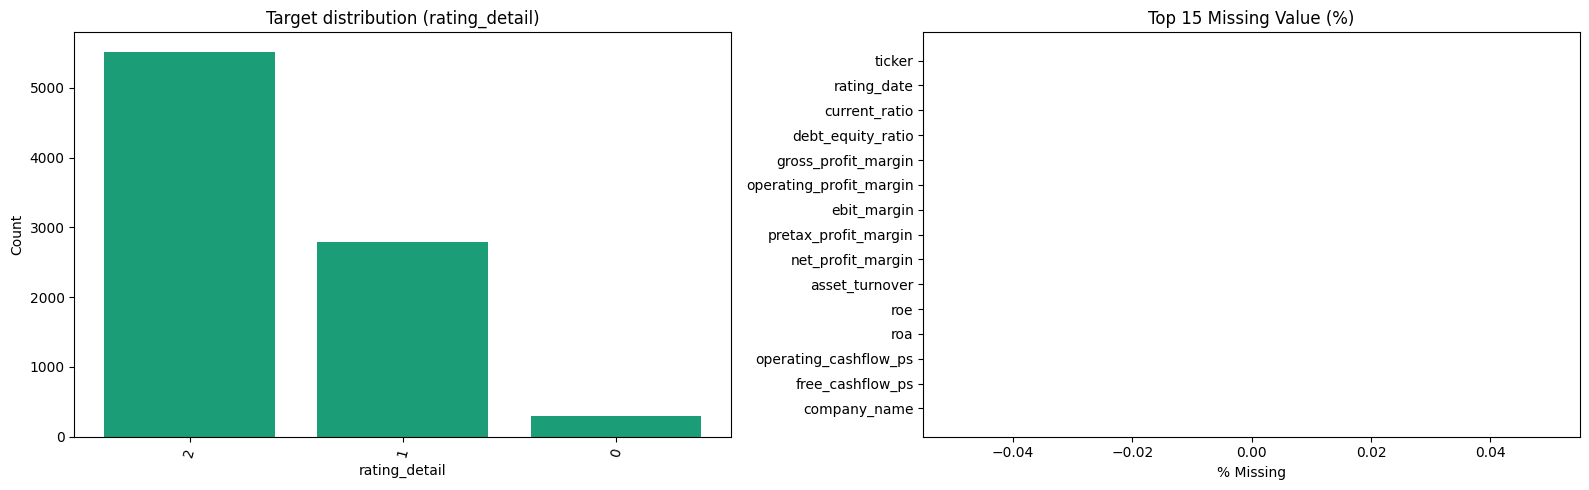

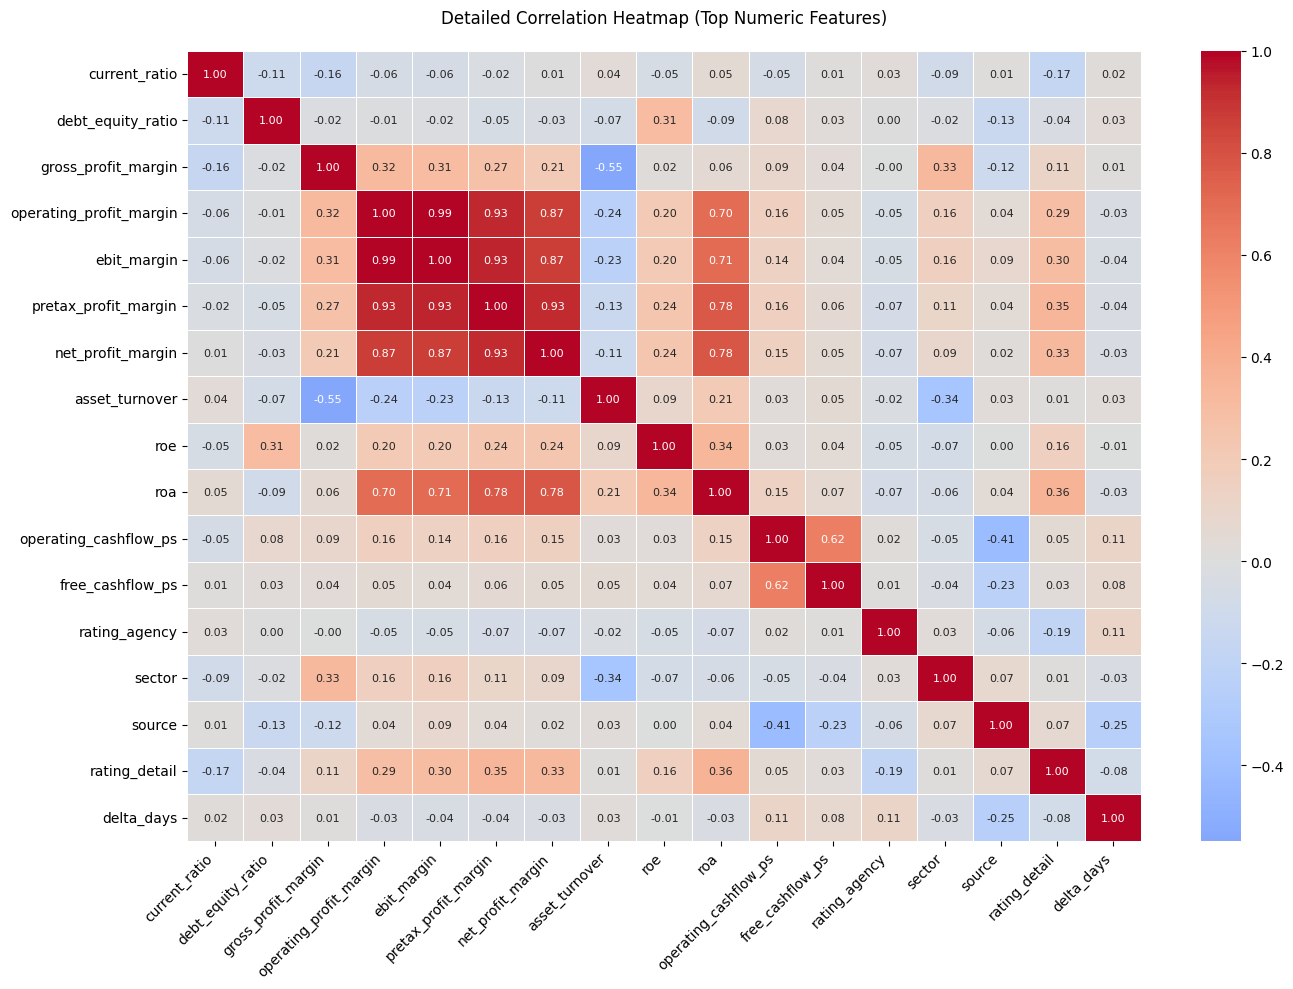

EDA plots saved successfully.


In [5]:
# Quick EDA: label distribution and missing-value ratio.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

target_counts = df['rating_detail'].value_counts().sort_values(ascending=False)
axes[0].bar(target_counts.index.astype(str), target_counts.values, color='#1b9e77')
axes[0].set_title('Target distribution (rating_detail)')
axes[0].set_xlabel('rating_detail')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=75)

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct.head(15)
axes[1].barh(top_missing.index[::-1], top_missing.values[::-1], color='#7570b3')
axes[1].set_title('Top 15 Missing Value (%)')
axes[1].set_xlabel('% Missing')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'eda_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap for up to 20 numeric columns, excluding binary target if present.
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_corr = [c for c in num_cols_all if c not in ['binary_rating']][:20]
if len(num_cols_corr) >= 2:
    corr = df[num_cols_corr].corr()
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr,
        cmap='coolwarm',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        annot_kws={'size': 8},
    )
    plt.title('Detailed Correlation Heatmap (Top Numeric Features)', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'eda_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[INFO] Not enough numeric columns for correlation heatmap.')

print('EDA plots saved successfully.')


## 3. Target Validation and Feature Preprocessing

Xác thực biến mục tiêu, chuẩn hóa cột đặc trưng  và  chuẩn bị dữ liệu nhất quán giữa train/val/test.


In [6]:

FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio',
    'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin',
    'net_profit_margin', 'asset_turnover',
    'roe', 'roa',
    'operating_cashflow_ps', 'free_cashflow_ps'
]

SECTOR_COL = 'sector'
SECTOR_UNKNOWN = 'UNKNOWN'
TICKER_COL = 'ticker'
COMPANY_COL = 'company_name'
TARGET_COL = 'rating_detail'

# If labels are strings, keep this risk order when available.
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']

before_rows = len(df)
df = df.dropna(subset=[TARGET_COL]).copy().reset_index(drop=True)
df['row_id'] = np.arange(len(df), dtype=int)

target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed_classes_raw = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(raw): idx for idx, raw in enumerate(observed_classes_raw)}
    id_to_raw = {idx: int(raw) for raw, idx in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    target_as_str = df[TARGET_COL].astype(str).str.strip()
    observed_str = sorted(target_as_str.unique().tolist())
    if set(observed_str).issubset(set(TARGET_ORDERED_LABELS)):
        ordered_present = [c for c in TARGET_ORDERED_LABELS if c in observed_str]
    else:
        ordered_present = observed_str
    raw_to_id = {raw: idx for idx, raw in enumerate(ordered_present)}
    id_to_raw = {idx: raw for raw, idx in raw_to_id.items()}
    df[TARGET_COL] = target_as_str.map(raw_to_id).astype(int)

EXPECTED_CLASSES = sorted(df[TARGET_COL].unique().tolist())
if EXPECTED_CLASSES != list(range(len(EXPECTED_CLASSES))):
    raise ValueError(f'Label IDs must be contiguous from 0. Got: {EXPECTED_CLASSES}')

n_classes = len(EXPECTED_CLASSES)
TARGET_MIN, TARGET_MAX = 0, n_classes - 1

class _StaticLabelEncoder:
    def __init__(self, classes):
        self.classes_ = np.array(classes, dtype=object)

le = _StaticLabelEncoder(classes=[id_to_raw[i] for i in range(n_classes)])

df['rating_date'] = pd.to_datetime(df['rating_date'], format='mixed')
df[TICKER_COL] = df[TICKER_COL].fillna('UNKNOWN_TICKER').astype(str).str.strip()
df[COMPANY_COL] = df[COMPANY_COL].fillna('UNKNOWN_COMPANY').astype(str).str.strip()

if SECTOR_COL not in df.columns:
    df[SECTOR_COL] = SECTOR_UNKNOWN
df[SECTOR_COL] = df[SECTOR_COL].fillna(SECTOR_UNKNOWN).astype(str).str.strip()
df.loc[df[SECTOR_COL] == '', SECTOR_COL] = SECTOR_UNKNOWN

split_series = df['__split__'].astype(str).str.lower()
train_mask_raw = split_series == 'train'
has_train_rows = bool(train_mask_raw.any())
stats_ref = df.loc[train_mask_raw].copy() if has_train_rows else df.copy()

sector_encoder = LabelEncoder()
sector_encoder.fit(stats_ref[SECTOR_COL])
SECTOR_CLASSES = sector_encoder.classes_.tolist()
_UNKNOWN_SECTOR_ID = len(SECTOR_CLASSES)

def _encode_from_classes(val, classes, encoder, unknown_id):
    return int(encoder.transform([val])[0]) if val in classes else int(unknown_id)

df['sector_id'] = df[SECTOR_COL].apply(
    lambda val: _encode_from_classes(val, sector_encoder.classes_, sector_encoder, _UNKNOWN_SECTOR_ID)
)
n_sectors = len(SECTOR_CLASSES) + 1

ticker_encoder = LabelEncoder()
ticker_encoder.fit(stats_ref[TICKER_COL])
TICKER_CLASSES = ticker_encoder.classes_.tolist()
_UNKNOWN_TICKER_ID = len(TICKER_CLASSES)
df['ticker_id'] = df[TICKER_COL].apply(
    lambda val: _encode_from_classes(val, ticker_encoder.classes_, ticker_encoder, _UNKNOWN_TICKER_ID)
)
n_tickers = len(TICKER_CLASSES) + 1

company_encoder = LabelEncoder()
company_encoder.fit(stats_ref[COMPANY_COL])
COMPANY_CLASSES = company_encoder.classes_.tolist()
_UNKNOWN_COMPANY_ID = len(COMPANY_CLASSES)
df['company_id'] = df[COMPANY_COL].apply(
    lambda val: _encode_from_classes(val, company_encoder.classes_, company_encoder, _UNKNOWN_COMPANY_ID)
)
n_companies = len(COMPANY_CLASSES) + 1

print(f'[P1 Fix 4 OK] Sector encoder fit on train only: {len(SECTOR_CLASSES)} known + 1 unknown')
val_unknown = (df.loc[df['__split__'] == 'val', 'sector_id'] == _UNKNOWN_SECTOR_ID).sum()
test_unknown = (df.loc[df['__split__'] == 'test', 'sector_id'] == _UNKNOWN_SECTOR_ID).sum()
print(f'  Unknown sectors: val={val_unknown}, test={test_unknown}')
print(f'[P3] Entity encoders: tickers={len(TICKER_CLASSES)} + 1 unknown, companies={len(COMPANY_CLASSES)} + 1 unknown')

for col in FINANCIAL_FEATURES:
    med = stats_ref[col].median() if stats_ref[col].notna().any() else df[col].median()
    if pd.isna(med):
        med = 0.0
    if df[col].isna().any():
        df[col] = df[col].fillna(float(med))

for col in FINANCIAL_FEATURES:
    lower = stats_ref[col].quantile(0.01)
    upper = stats_ref[col].quantile(0.99)
    if pd.isna(lower) or pd.isna(upper):
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
    if pd.isna(lower) or pd.isna(upper):
        continue
    df[col] = df[col].clip(float(lower), float(upper))

print(f'Rows kept after target cleanup: {len(df)} / {before_rows}')
print(f'Number of classes (observed): {n_classes}')
print(f'Label range (model IDs): {TARGET_MIN}..{TARGET_MAX}')
print('Observed label IDs:', sorted(df[TARGET_COL].unique().tolist()))
print('Raw-to-ID mapping:', raw_to_id)
print('Decoder classes (ID -> raw):', le.classes_.tolist())
print(f'Sectors encoded: {n_sectors}')
print(f'Tickers encoded: {n_tickers}')
print(f'Companies encoded: {n_companies}')
print(f"Leakage guard reference split: {'train' if has_train_rows else 'all_data_fallback'}")
print('Sample sectors:', SECTOR_CLASSES[:10])
print(f'\nData after preprocessing: {df.shape}')

_TEMPORAL_FEATURES = ['delta_days']
_available_temporal = [f for f in _TEMPORAL_FEATURES if f in df.columns]
if _available_temporal:
    FINANCIAL_FEATURES = FINANCIAL_FEATURES + _available_temporal
    print(f'[P1 Fix 6 OK] Added temporal features: {_available_temporal}')
else:
    print('[P1 Fix 6 INFO] delta_days not in data, skipping.')

if 'validate_feature_alignment_with_metadata' in globals():
    validate_feature_alignment_with_metadata()


[P1 Fix 4 OK] Sector encoder fit on train only: 12 known + 1 unknown
  Unknown sectors: val=0, test=0
[P3] Entity encoders: tickers=842 + 1 unknown, companies=1514 + 1 unknown
Rows kept after target cleanup: 8614 / 8614
Number of classes (observed): 3
Label range (model IDs): 0..2
Observed label IDs: [0, 1, 2]
Raw-to-ID mapping: {0: 0, 1: 1, 2: 2}
Decoder classes (ID -> raw): [0, 1, 2]
Sectors encoded: 13
Tickers encoded: 843
Companies encoded: 1515
Leakage guard reference split: train
Sample sectors: ['0', '1', '10', '11', '2', '3', '4', '5', '6', '7']

Data after preprocessing: (8614, 25)
[P1 Fix 6 OK] Added temporal features: ['delta_days']
[OK] 13 financial features match TimeGAN metadata.
[OK] 13 financial features are present in train_df.


In [7]:
# AGENT_FIX [P1] Validation — sector encoder only from train
train_sectors_set = set(df.loc[df['__split__'] == 'train', SECTOR_COL].unique())
for cls in sector_encoder.classes_:
    assert cls in train_sectors_set, f'[P1 FAIL] Sector {cls!r} not in train — leakage!'
print(f'[P1 Fix 4 Validation OK] All {len(sector_encoder.classes_)} sector classes from train')

[P1 Fix 4 Validation OK] All 12 sector classes from train


## 4. Panel Time-Series Construction

Chuyển dữ liệu về dạng panel theo ticker  và  timeline để tạo đầu vào chuỗi thời gian ổn định.


In [8]:

df_sorted = df.sort_values(['ticker', 'rating_date', 'row_id']).reset_index(drop=True)

panel_df = df_sorted[
    ['row_id', 'ticker', 'company_name', 'rating_date', 'rating_detail',
     'sector_id', 'ticker_id', 'company_id', '__split__'] + FINANCIAL_FEATURES
].copy()
panel_df = panel_df.rename(columns={
    'ticker': 'unique_id',
    'rating_date': 'ds',
    'rating_detail': 'y'
})

ticker_counts = panel_df.groupby('unique_id').size().reset_index(name='count')
print('Ticker count statistics:')
print(ticker_counts['count'].describe())
print()

MIN_HISTORY = 1
valid_tickers = ticker_counts[ticker_counts['count'] >= MIN_HISTORY]['unique_id'].tolist()
panel_df = panel_df[panel_df['unique_id'].isin(valid_tickers)].reset_index(drop=True)
row_level_reference = panel_df[['row_id', 'unique_id', 'company_name', 'ds', 'y', '__split__']].copy()

print(f'Tickers with >= {MIN_HISTORY} data points: {len(valid_tickers)}')
print(f'Panel DataFrame shape: {panel_df.shape}')
print(f'Unique tickers: {panel_df["unique_id"].nunique()}')
print(f'Unique companies: {panel_df["company_name"].nunique()}')
print(f'Date range: {panel_df["ds"].min()} to {panel_df["ds"].max()}')
print(f'Unique sectors (encoded): {panel_df["sector_id"].nunique()}')
print('Split distribution:')
print(panel_df['__split__'].value_counts())
display(panel_df.head(10))


Ticker count statistics:
count    886.000000
mean       9.722348
std        8.522996
min        1.000000
25%        3.000000
50%        6.000000
75%       16.000000
max       43.000000
Name: count, dtype: float64

Tickers with >= 1 data points: 886
Panel DataFrame shape: (8614, 22)
Unique tickers: 886
Unique companies: 1614
Date range: 2005-08-16 00:00:00 to 2016-12-27 00:00:00
Unique sectors (encoded): 12
Split distribution:
__split__
train    6029
test     1723
val       862
Name: count, dtype: int64


,row_id,unique_id,company_name,ds,y,sector_id,ticker_id,company_id,__split__,current_ratio,...,operating_profit_margin,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,roe,roa,operating_cashflow_ps,free_cashflow_ps,delta_days
0,6087,AA,Alcoa Corporation,2015-10-14,1,0,842,1514,val,-0.690769,...,-0.905683,-0.977472,-0.952038,-1.141099,-0.127150,-0.528122,-1.616468,1.432948,0.688766,0.182969
1,6931,AAL,"American Airlines Group, Inc.",2013-11-12,1,3,0,92,test,-0.731203,...,-0.471311,-1.445823,-1.233950,-1.075691,-0.228894,1.275889,-1.469018,1.314448,-3.579942,0.182969
2,2576,AAL,"American Airlines Group, Inc.",2015-06-30,1,3,0,92,train,-0.922569,...,2.209175,2.211901,2.214028,2.255362,-1.443413,3.059869,0.315088,1.343857,-1.121070,1.390993
3,6727,AAP,"Advance Auto Parts, Inc.",2012-06-15,2,6,1,58,val,-0.716343,...,-0.080014,-0.068947,0.071325,-0.015327,1.460299,0.788620,0.965990,1.090507,0.465315,0.182969
4,7706,AAP,"ADVANCE AUTO PARTS, INC.",2013-05-29,2,6,1,12,test,-0.463556,...,-0.092279,-0.081204,0.057542,-0.026650,0.997811,0.445128,0.599158,-1.246011,-0.650242,1.351956
5,3997,AAP,"ADVANCE AUTO PARTS, INC.",2013-09-25,2,6,1,12,train,-0.463556,...,-0.092279,-0.081204,0.057542,-0.026650,0.997811,0.445128,0.599158,-1.246011,-0.650242,0.475718
6,5805,AAP,"ADVANCE AUTO PARTS, INC.",2013-11-13,2,6,1,12,train,-0.463556,...,-0.092279,-0.081204,0.057542,-0.026650,0.997811,0.445128,0.599158,-1.246011,-0.650242,-0.242841
7,7217,AAP,"Advance Auto Parts, Inc.",2013-11-25,2,6,1,58,test,-0.463556,...,-0.092279,-0.081204,0.057542,-0.026650,0.997811,0.445128,0.599158,-1.246011,-0.650242,-1.348479
8,6440,AAP,"ADVANCE AUTO PARTS, INC.",2014-02-21,2,6,1,12,val,-0.228162,...,-0.121636,-0.110541,0.029770,-0.043387,0.730520,0.298944,0.386745,-1.368146,-0.347717,0.230426
9,1290,AAP,"ADVANCE AUTO PARTS, INC.",2014-06-18,2,6,1,12,train,-0.228162,...,-0.121636,-0.110541,0.029770,-0.043387,0.730520,0.298944,0.386745,-1.368146,-0.347717,0.461923


## 5. Sliding Windows, Split, and DataLoaders

Tạo mẫu cửa sổ thời gian, chia train/val/test theo nguyên tắc chống leakage  và  build DataLoader.


In [9]:

# Row-level temporal context builder: one sequence per row, ending at the current row.
HORIZON = 1
WINDOW_PADDING_MODE = 'edge'
INPUT_SIZE_SEARCH_ENABLED = True
INPUT_SIZE_DEFAULT = 8  # Aligned sequence length to 8 quarters (2 years)
INPUT_SIZE_MIN = 1
INPUT_SIZE_MAX = 12
ENABLE_SYNTH_QC = True
ENABLE_WEIGHTED_SAMPLER = True
SAMPLER_WEIGHT_POWER = 0.85

INPUT_SIZE = int(np.clip(INPUT_SIZE_DEFAULT, INPUT_SIZE_MIN, INPUT_SIZE_MAX))
input_size_reason = 'fixed_row_level_current_step'
INPUT_SIZE_SEARCH_REPORT = pd.DataFrame([{
    'input_size': int(INPUT_SIZE),
    'train_windows': int((panel_df['__split__'] == 'train').sum()),
    'val_windows': int((panel_df['__split__'] == 'val').sum()),
    'test_windows': int((panel_df['__split__'] == 'test').sum()),
    'total_windows': int(len(panel_df)),
    'padded_windows_total': int(0),
    'score': 1.0,
}])

print(f'INPUT_SIZE selected: {INPUT_SIZE} ({input_size_reason})')
print(f'HORIZON (forecast): {HORIZON}')
print(f'Window padding mode: {WINDOW_PADDING_MODE}')
print(INPUT_SIZE_SEARCH_REPORT.to_string(index=False))

panel_df_filtered = panel_df.sort_values(['unique_id', 'ds', 'row_id']).reset_index(drop=True)
print(f'Panel shape for row-level sequence generation: {panel_df_filtered.shape}')

DELTA_FEATURES = []
for col in FINANCIAL_FEATURES:
    dcol = f'{col}_delta'
    panel_df_filtered[dcol] = panel_df_filtered.groupby('unique_id')[col].diff().fillna(0.0)
    DELTA_FEATURES.append(dcol)

MODEL_FEATURES = FINANCIAL_FEATURES + DELTA_FEATURES
train_mask_clip = panel_df_filtered['__split__'] == 'train'
for col in MODEL_FEATURES:
    col_vals = panel_df_filtered.loc[train_mask_clip, col]
    lo = col_vals.quantile(0.001)
    hi = col_vals.quantile(0.999)
    panel_df_filtered[col] = panel_df_filtered[col].clip(lo, hi)

print('[P0 Fix 1 OK] RobustScaler removed. Using StandardScaled values from TimeGAN.')
print(f"  MODEL_FEATURES mean (train): {panel_df_filtered.loc[train_mask_clip, MODEL_FEATURES].mean().round(3).to_dict()}")
print(f"  MODEL_FEATURES std  (train): {panel_df_filtered.loc[train_mask_clip, MODEL_FEATURES].std().round(3).to_dict()}")

SEQ_X_IDX = 0
SEQ_LAST_Y_IDX = 1
SEQ_SECTOR_IDX = 2
SEQ_TICKER_IDX = 3
SEQ_COMPANY_IDX = 4
SEQ_TARGET_IDX = 5
SEQ_ROW_ID_IDX = 6

class CreditRatingDataset(Dataset):
    """Row-level dataset with temporal context ending at the current row."""
    def __init__(self, sequences, augment=False, noise_std=0.0, feature_dropout_prob=0.0):
        self.sequences = sequences
        self.augment = augment
        self.noise_std = float(noise_std)
        self.feature_dropout_prob = float(feature_dropout_prob)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        X, last_y, sector_id, ticker_id, company_id, y_target, row_id = self.sequences[idx]
        X = np.asarray(X, dtype=np.float32).copy()

        if self.augment:
            if self.noise_std > 0:
                X += np.random.normal(0.0, self.noise_std, size=X.shape).astype(np.float32)
            if self.feature_dropout_prob > 0:
                drop_mask = np.random.rand(X.shape[1]) < self.feature_dropout_prob
                if drop_mask.any():
                    X[:, drop_mask] = 0.0

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(last_y, dtype=torch.long),
            torch.tensor(sector_id, dtype=torch.long),
            torch.tensor(ticker_id, dtype=torch.long),
            torch.tensor(company_id, dtype=torch.long),
            torch.tensor(y_target, dtype=torch.long),
            torch.tensor(row_id, dtype=torch.long),
        )

def build_context_window(values, target_idx, input_size, mode='edge'):
    start_idx = max(0, target_idx - input_size + 1)
    X_raw = values[start_idx:target_idx + 1]
    if X_raw.shape[0] >= input_size:
        return X_raw[-input_size:]

    pad_len = input_size - X_raw.shape[0]
    if mode == 'zero':
        pad_block = np.zeros((pad_len, X_raw.shape[1]), dtype=X_raw.dtype)
    else:
        pad_block = np.repeat(X_raw[[0]], pad_len, axis=0)
    return np.concatenate([pad_block, X_raw], axis=0)

feature_cols = MODEL_FEATURES
n_channels = len(feature_cols)

train_seqs = []
val_seqs = []
test_seqs = []
test_seq_tickers = []
test_seq_row_ids = []
train_seq_is_synth = []
train_seq_is_change = []
has_synth_col = 'is_synthetic' in panel_df_filtered.columns
padded_window_count = 0

for uid, grp in panel_df_filtered.groupby('unique_id'):
    grp = grp.sort_values('ds').reset_index(drop=True)
    values = grp[feature_cols].values
    n = len(values)
    if n == 0:
        continue

    for target_idx in range(n):
        X = build_context_window(values, target_idx=target_idx, input_size=INPUT_SIZE, mode=WINDOW_PADDING_MODE)
        if X is None or X.shape[0] != INPUT_SIZE:
            continue

        if target_idx < INPUT_SIZE - 1:
            padded_window_count += 1

        last_y_idx = max(0, target_idx - 1)
        sample = (
            X,
            int(grp['y'].iloc[last_y_idx]),
            int(grp['sector_id'].iloc[target_idx]),
            int(grp['ticker_id'].iloc[target_idx]),
            int(grp['company_id'].iloc[target_idx]),
            int(grp['y'].iloc[target_idx]),
            int(grp['row_id'].iloc[target_idx]),
        )
        split_label = str(grp['__split__'].iloc[target_idx]).lower()

        if split_label == 'test':
            test_seqs.append(sample)
            test_seq_tickers.append(uid)
            test_seq_row_ids.append(int(grp['row_id'].iloc[target_idx]))
        elif split_label == 'val':
            val_seqs.append(sample)
        else:
            train_seqs.append(sample)
            train_seq_is_change.append(int(grp['y'].iloc[target_idx] != grp['y'].iloc[last_y_idx]))
            if has_synth_col:
                train_seq_is_synth.append(int(grp['is_synthetic'].iloc[target_idx]))
            else:
                train_seq_is_synth.append(0)

if len(train_seqs) == 0 or len(val_seqs) == 0 or len(test_seqs) == 0:
    raise ValueError(
        f'Empty split sequences found: train={len(train_seqs)}, val={len(val_seqs)}, test={len(test_seqs)}.'
    )

test_seq_tickers = np.array(test_seq_tickers, dtype=object)
test_seq_row_ids = np.array(test_seq_row_ids, dtype=int)
train_seq_is_synth = np.array(train_seq_is_synth, dtype=int)
train_seq_is_change = np.array(train_seq_is_change, dtype=int)

SYNTH_MAX_ABS_FEATURE = 6.0
SYNTH_MAX_RATIO = 0.45
train_seqs_before_synth_qc = len(train_seqs)
if ENABLE_SYNTH_QC and has_synth_col and len(train_seqs) > 0:
    seq_max_abs = np.array([float(np.max(np.abs(s[SEQ_X_IDX]))) for s in train_seqs], dtype=np.float32)
    keep_mask = np.ones(len(train_seqs), dtype=bool)
    synth_mask = train_seq_is_synth == 1
    keep_mask[synth_mask & (seq_max_abs > SYNTH_MAX_ABS_FEATURE)] = False

    kept_synth_idx = np.where(keep_mask & synth_mask)[0]
    kept_real_idx = np.where(keep_mask & (~synth_mask))[0]
    max_synth_keep = int(len(kept_real_idx) * SYNTH_MAX_RATIO / max(1e-9, 1.0 - SYNTH_MAX_RATIO))
    if len(kept_synth_idx) > max_synth_keep > 0:
        rng_seq = np.random.default_rng(SEED)
        drop_idx = rng_seq.choice(
            kept_synth_idx,
            size=len(kept_synth_idx) - max_synth_keep,
            replace=False,
        )
        keep_mask[drop_idx] = False

    if not keep_mask.all():
        train_seqs = [s for s, k in zip(train_seqs, keep_mask) if k]
        train_seq_is_synth = train_seq_is_synth[keep_mask]
        train_seq_is_change = train_seq_is_change[keep_mask]
train_seqs_after_synth_qc = len(train_seqs)

TRAIN_WINDOW_NOISE_STD = 0.02
TRAIN_FEATURE_DROPOUT = 0.10

train_ds = CreditRatingDataset(train_seqs, augment=True, noise_std=TRAIN_WINDOW_NOISE_STD, feature_dropout_prob=TRAIN_FEATURE_DROPOUT)
val_ds = CreditRatingDataset(val_seqs, augment=False)
test_ds = CreditRatingDataset(test_seqs, augment=False)

train_labels = np.array([s[SEQ_TARGET_IDX] for s in train_seqs], dtype=int)
class_freq_raw = np.bincount(train_labels, minlength=n_classes).astype(float)
non_zero_freq = class_freq_raw[class_freq_raw > 0]
imbalance_ratio = float(class_freq_raw.max() / non_zero_freq.min()) if len(non_zero_freq) > 0 else 1.0
synthetic_ratio_train = float(train_seq_is_synth.mean()) if len(train_seq_is_synth) > 0 else 0.0
transition_ratio_train = float(train_seq_is_change.mean()) if len(train_seq_is_change) > 0 else 0.0

weighted_sampler = None
if ENABLE_WEIGHTED_SAMPLER and len(train_labels) > 0:
    class_weights = np.zeros_like(class_freq_raw, dtype=np.float64)
    non_zero_mask = class_freq_raw > 0
    class_weights[non_zero_mask] = class_freq_raw[non_zero_mask].sum() / class_freq_raw[non_zero_mask]
    sample_weights = np.power(class_weights[train_labels], SAMPLER_WEIGHT_POWER)
    weighted_sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

BATCH_SIZE = 64
NUM_WORKERS = 4 if IN_KAGGLE else 0
PIN_MEMORY = (device.type == 'cuda')

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(weighted_sampler is None),
    sampler=weighted_sampler,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f'\nChannels: {n_channels}')
print(f'Base features: {len(FINANCIAL_FEATURES)} | Delta features: {len(DELTA_FEATURES)}')
print(f'Train samples: {len(train_ds)}')
print(f'Val samples:   {len(val_ds)}')
print(f'Test samples:  {len(test_ds)}')
print(f'Test ticker refs: {len(test_seq_tickers)} | row ids: {len(test_seq_row_ids)}')
print(f'Padded row-level windows: {padded_window_count}')
print(f'Synth QC enabled: {ENABLE_SYNTH_QC} | removed windows: {train_seqs_before_synth_qc - train_seqs_after_synth_qc}')
print(f'Train synthetic ratio (rows): {synthetic_ratio_train:.3f}')
print(f'Train transition ratio (y_t != y_t-1): {transition_ratio_train:.3f}')
print(f'Train class freq min/max: {class_freq_raw.min():.0f}/{class_freq_raw.max():.0f}')
print(f'Imbalance ratio (max/min non-zero): {imbalance_ratio:.2f}')
print(f'Weighted sampler enabled: {weighted_sampler is not None}')
print(f'Sampler weight power: {SAMPLER_WEIGHT_POWER}')
print(f'Train window noise std: {TRAIN_WINDOW_NOISE_STD}')
print(f'Train feature dropout prob: {TRAIN_FEATURE_DROPOUT}')

sample_X, sample_last_y, sample_sector_id, sample_ticker_id, sample_company_id, sample_y, sample_row_id = train_ds[0]
print(f'\nSample X shape: {sample_X.shape}  (T, C)')
print(f'Sample last_y: {sample_last_y}')
print(f'Sample sector_id: {sample_sector_id}')
print(f'Sample ticker_id: {sample_ticker_id}')
print(f'Sample company_id: {sample_company_id}')
print(f'Sample y: {sample_y} | row_id: {sample_row_id}')


INPUT_SIZE selected: 8 (fixed_row_level_current_step)
HORIZON (forecast): 1
Window padding mode: edge
 input_size  train_windows  val_windows  test_windows  total_windows  padded_windows_total  score
          8           6029          862          1723           8614                     0    1.0
Panel shape for row-level sequence generation: (8614, 22)
[P0 Fix 1 OK] RobustScaler removed. Using StandardScaled values from TimeGAN.
  MODEL_FEATURES mean (train): {'current_ratio': 0.0, 'debt_equity_ratio': -0.0, 'gross_profit_margin': -0.0, 'operating_profit_margin': 0.0, 'ebit_margin': -0.0, 'pretax_profit_margin': 0.0, 'net_profit_margin': 0.0, 'asset_turnover': -0.0, 'roe': 0.0, 'roa': -0.0, 'operating_cashflow_ps': -0.0, 'free_cashflow_ps': 0.0, 'delta_days': -0.0, 'current_ratio_delta': -0.002, 'debt_equity_ratio_delta': 0.019, 'gross_profit_margin_delta': -0.0, 'operating_profit_margin_delta': -0.021, 'ebit_margin_delta': -0.02, 'pretax_profit_margin_delta': -0.017, 'net_profit_marg

In [10]:
# AGENT_FIX [P0] Validation — mean ~0, std ~1 (StandardScaled)
train_stats = panel_df_filtered.loc[panel_df_filtered['__split__'] == 'train', MODEL_FEATURES]
mean_abs = train_stats.mean().abs().max()
std_range = (train_stats.std() - 1).abs().max()
assert mean_abs < 1.5, f'[P0 FAIL] Mean too large ({mean_abs:.3f}), suspect double scaling'
assert std_range < 1.5, f'[P0 FAIL] Std far from 1 ({std_range:.3f}), suspect bad scaling'
print(f'[P0 Validation OK] max|mean|={mean_abs:.3f}, max|std-1|={std_range:.3f}')

[P0 Validation OK] max|mean|=0.029, max|std-1|=0.854


In [11]:
# AGENT_FIX [P0] Validation — INPUT_SIZE and sequence counts
assert INPUT_SIZE >= 1, f'[P0 FAIL] INPUT_SIZE={INPUT_SIZE} too small'
assert len(train_seqs) > 0, '[P0 FAIL] train_seqs is empty after INPUT_SIZE change'
assert len(val_seqs)   > 0, '[P0 FAIL] val_seqs is empty'
assert len(test_seqs)  > 0, '[P0 FAIL] test_seqs is empty'
sample_X = train_seqs[0][0]
assert sample_X.shape[0] == INPUT_SIZE, f'[P0 FAIL] Window shape wrong: {sample_X.shape[0]} != {INPUT_SIZE}'
print(f'[P0 Fix 2 OK] INPUT_SIZE={INPUT_SIZE}, train={len(train_seqs)}, val={len(val_seqs)}, test={len(test_seqs)}')

[P0 Fix 2 OK] INPUT_SIZE=8, train=6029, val=862, test=1723


In [12]:
# ============================================================
# Deterministic DataLoader Rebuild (stability/reproducibility)
# ============================================================

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

weighted_sampler = None
if ENABLE_WEIGHTED_SAMPLER and len(train_labels) > 0:
    class_weights = np.zeros_like(class_freq_raw, dtype=np.float64)
    non_zero_mask = class_freq_raw > 0
    class_weights[non_zero_mask] = class_freq_raw[non_zero_mask].sum() / class_freq_raw[non_zero_mask]
    sample_weights = np.power(class_weights[train_labels], SAMPLER_WEIGHT_POWER)
    weighted_sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
        generator=loader_generator,
    )

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(weighted_sampler is None),
    sampler=weighted_sampler,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator if weighted_sampler is None else None,
 )

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
 )

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
 )

print('Rebuilt DataLoaders with deterministic generator and worker seeding.')
print(f'Weighted sampler enabled: {weighted_sampler is not None}')
print(f'Persistent workers: {bool(NUM_WORKERS > 0)}')

Rebuilt DataLoaders with deterministic generator and worker seeding.
Weighted sampler enabled: True
Persistent workers: True


## 6. Loss Function and Class-Imbalance Handling

Định nghĩa loss cho bài toán ordinal classification  và  xử lý mất cân bằng lớp.


In [13]:
def build_effective_num_class_weights(class_counts, beta=0.995):
    """Effective-number reweighting (Cui et al.) with mean=1 normalization."""
    counts = np.asarray(class_counts, dtype=np.float64)
    counts = np.maximum(counts, 0.0)
    weights = np.zeros_like(counts, dtype=np.float64)

    valid = counts > 0
    if valid.any():
        effective_num = 1.0 - np.power(float(beta), counts[valid])
        weights[valid] = (1.0 - float(beta)) / np.maximum(effective_num, 1e-12)
        weights[valid] = weights[valid] / np.mean(weights[valid])
    else:
        weights[:] = 1.0
    return weights


class FocalLoss(nn.Module):
    """Pure focal term + ordinal regularization with optional class-balance weights."""
    def __init__(self, n_classes, gamma=1.5, ordinal_alpha=0.04, label_smoothing=0.0, class_weights=None):
        super().__init__()
        self.n_classes = int(n_classes)
        self.gamma = float(gamma)
        self.ordinal_alpha = float(ordinal_alpha)
        self.label_smoothing = float(label_smoothing)
        if class_weights is None:
            self.class_weights = None
        else:
            cw = torch.tensor(class_weights, dtype=torch.float32)
            self.register_buffer('class_weights', cw)

    def forward(self, logits, targets):
        logits_for_loss = logits.float()
        log_probs = F.log_softmax(logits_for_loss, dim=1)
        probs = log_probs.exp()

        if self.label_smoothing > 0.0 and self.n_classes > 1:
            smooth = self.label_smoothing
            smooth_targets = torch.full_like(
                log_probs,
                fill_value=smooth / max(1, self.n_classes - 1),
            )
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - smooth)
            pt = (probs * smooth_targets).sum(dim=1).clamp(min=1e-8, max=1.0 - 1e-8)
        else:
            pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8, max=1.0 - 1e-8)

        focal_loss = -((1.0 - pt) ** self.gamma) * torch.log(pt)

        if self.class_weights is not None:
            weight = self.class_weights.to(device=logits.device, dtype=torch.float32)
            focal_loss = focal_loss * weight[targets]

        focal_term = focal_loss.mean()

        if self.ordinal_alpha <= 0.0:
            return focal_term

        class_positions = torch.arange(self.n_classes, device=logits.device, dtype=probs.dtype)
        expected_rank = (probs * class_positions.unsqueeze(0)).sum(dim=1)
        target_rank = targets.to(dtype=probs.dtype)
        denom = max(1.0, float(self.n_classes - 1))
        ordinal_loss = ((expected_rank - target_rank) / denom).pow(2).mean()

        # Unimodality penalty: cumulative probs must be monotone
        cumprobs = torch.cumsum(probs, dim=1)
        cum_violation = F.relu(-(cumprobs[:, 1:] - cumprobs[:, :-1])).sum(dim=1).mean()
        return focal_term + self.ordinal_alpha * ordinal_loss + 0.05 * cum_violation


CLASS_BALANCE_BETA = 0.995
class_weights_effective = build_effective_num_class_weights(
    class_freq_raw if 'class_freq_raw' in globals() else np.ones(n_classes),
    beta=CLASS_BALANCE_BETA,
 )

criterion_settings = {
    'loss_name': 'focal_ordinal_sampler_balanced',
    'focal_gamma': 1.5,
    'label_smoothing': 0.00,  # Audit Fix F7: 0.0 (no smoothing with focal)
    'ordinal_alpha': 0.12,  # Audit Fix F4: was 0.04
    'class_balance_beta': CLASS_BALANCE_BETA,
}

# Audit Fix F1: WeightedSampler already re-balances; class_weights=None
#               avoids double imbalance correction (EffectiveNum Ă¢â€°Ë† no-op at 1.81x ratio).
criterion = FocalLoss(
    n_classes=n_classes,
    gamma=criterion_settings['focal_gamma'],
    ordinal_alpha=criterion_settings['ordinal_alpha'],
    label_smoothing=criterion_settings['label_smoothing'],
    class_weights=None,  # Audit Fix F1: sampler handles imbalance
).to(device)

FOCAL_GAMMA = criterion_settings['focal_gamma']
print(
    f"Loss: {criterion_settings['loss_name']} | "
    f"gamma={criterion_settings['focal_gamma']} | "
    f"smoothing={criterion_settings['label_smoothing']} | "
    f"ordinal_alpha={criterion_settings['ordinal_alpha']} | "
    f"beta={criterion_settings['class_balance_beta']}"
 )
print('Effective class weights:', np.round(class_weights_effective, 4).tolist())

Loss: focal_ordinal_sampler_balanced | gamma=1.5 | smoothing=0.0 | ordinal_alpha=0.12 | beta=0.995
Effective class weights: [1.3092, 0.8454, 0.8454]


## 5. Model Architecture

Khai bao Transformer temporal block nhe, LSTM mot chieu, entity embeddings va head phan loai.


In [ ]:

class TemporalSelfAttentionBlock(nn.Module):
    """Pre-norm Transformer block with learnable relative positional bias."""
    def __init__(self, d_model=128, n_heads=4, dropout=0.1, max_relative_position=32):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.max_relative_position = int(max_relative_position)
        self.relative_bias = nn.Parameter(torch.zeros(2 * self.max_relative_position + 1))

    def _relative_bias_matrix(self, seq_len, device, dtype):
        pos = torch.arange(seq_len, device=device)
        rel = pos[None, :] - pos[:, None]
        rel = rel.clamp(-self.max_relative_position, self.max_relative_position)
        rel = rel + self.max_relative_position
        return self.relative_bias[rel].to(dtype=dtype)

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_bias = self._relative_bias_matrix(x.size(1), x.device, x.dtype)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm, attn_mask=attn_bias, need_weights=False)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


class AttentivePool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        ctx = (w * x).sum(dim=1)
        return ctx, w


class TransformerLSTMClassifier(nn.Module):
    """Pure Transformer-LSTM classifier for row-level credit-rating sequences."""
    def __init__(
        self,
        n_channels,
        n_classes,
        n_sectors,
        n_tickers,
        n_companies,
        hidden_size=64,
        dropout=0.25,
        d_model=64,
        n_heads=4,
        n_layers=1,
        sector_emb_dim=16,
        ticker_emb_dim=4,
        company_emb_dim=4,
        max_relative_position=8,
    ):
        super().__init__()
        self.n_layers = int(n_layers)

        self.input_norm = nn.LayerNorm(n_channels)
        self.input_proj = nn.Sequential(
            nn.Linear(n_channels, d_model),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        self.blocks = nn.ModuleList([
            TemporalSelfAttentionBlock(
                d_model=d_model,
                n_heads=n_heads,
                dropout=dropout,
                max_relative_position=max_relative_position,
            )
            for _ in range(self.n_layers)
        ])
        self.pre_lstm_norm = nn.LayerNorm(d_model)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            batch_first=True,
        )
        self.lstm_out_dim = hidden_size
        self.attn_pool = AttentivePool(self.lstm_out_dim)
        self.last_y_embed = nn.Embedding(n_classes, hidden_size)
        self.sector_embed = nn.Embedding(n_sectors, sector_emb_dim)
        self.ticker_embed = nn.Embedding(n_tickers, ticker_emb_dim)
        self.company_embed = nn.Embedding(n_companies, company_emb_dim)
        self.emb_dropout = nn.Dropout(dropout)

        transition_in_dim = self.lstm_out_dim + sector_emb_dim + ticker_emb_dim + company_emb_dim
        self.transition_head = nn.Sequential(
            nn.Linear(transition_in_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

        head_in_dim = self.lstm_out_dim + hidden_size + sector_emb_dim + ticker_emb_dim + company_emb_dim
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(head_in_dim, hidden_size * 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.8),
            nn.Linear(hidden_size * 2, n_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, x, last_y, sector_id, ticker_id=None, company_id=None, return_aux=False):
        x_features = self.input_norm(x)
        x_embed = self.input_proj(x_features)
        for blk in self.blocks:
            x_embed = blk(x_embed)
        x_embed = self.pre_lstm_norm(x_embed)
        lstm_out, _ = self.lstm(x_embed)
        seq_ctx, _ = self.attn_pool(lstm_out)

        batch_size = x.size(0)
        if ticker_id is None:
            ticker_id = torch.zeros(batch_size, dtype=torch.long, device=x.device)
        if company_id is None:
            company_id = torch.zeros(batch_size, dtype=torch.long, device=x.device)

        last_y_emb = self.emb_dropout(self.last_y_embed(last_y))
        sector_emb = self.emb_dropout(self.sector_embed(sector_id))
        ticker_emb = self.emb_dropout(self.ticker_embed(ticker_id))
        company_emb = self.emb_dropout(self.company_embed(company_id))
        aux_context = torch.cat([seq_ctx, sector_emb, ticker_emb, company_emb], dim=-1)
        transition_logits = self.transition_head(aux_context).squeeze(-1)

        out = torch.cat([seq_ctx, last_y_emb, sector_emb, ticker_emb, company_emb], dim=-1)
        logits = self.head(out)
        if return_aux:
            return logits, transition_logits
        return logits


MODEL_D_MODEL = 96
TRANSFORMER_HEADS = 4
TRANSFORMER_LAYERS = 2
LSTM_HIDDEN = 96
SECTOR_EMB_DIM = 16
TICKER_EMB_DIM = 16
COMPANY_EMB_DIM = 16
TLSTM_DROPOUT = 0.38
MAX_RELATIVE_POSITION = 8

model = TransformerLSTMClassifier(
    n_channels=n_channels,
    n_classes=n_classes,
    n_sectors=n_sectors,
    n_tickers=n_tickers,
    n_companies=n_companies,
    hidden_size=LSTM_HIDDEN,
    dropout=TLSTM_DROPOUT,
    d_model=MODEL_D_MODEL,
    n_heads=TRANSFORMER_HEADS,
    n_layers=TRANSFORMER_LAYERS,
    sector_emb_dim=SECTOR_EMB_DIM,
    ticker_emb_dim=TICKER_EMB_DIM,
    company_emb_dim=COMPANY_EMB_DIM,
    max_relative_position=MAX_RELATIVE_POSITION,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Pure Transformer-LSTM model created successfully!')
print(f'Projected d_model: {MODEL_D_MODEL}')
print(f'Transformer layers/heads: {TRANSFORMER_LAYERS}/{TRANSFORMER_HEADS}')
print(f'Relative position window: +/-{MAX_RELATIVE_POSITION}')
print(f'LSTM hidden size: {LSTM_HIDDEN} | direction=single')
print(f'Sector embedding dim: {SECTOR_EMB_DIM}')
print(f'Ticker embedding dim: {TICKER_EMB_DIM}')
print(f'Company embedding dim: {COMPANY_EMB_DIM}')
print(f'Channels: {n_channels} (base + delta features)')
print(f'Sectors: {n_sectors} | Tickers: {n_tickers} | Companies: {n_companies}')
print(f'Model parameters: {n_params:,}')
print(model)


In [ ]:
# ============================================================
# Cell 24: PriMO HPO via NePS (Neural Pipeline Search)
# ============================================================
# Paper: Basu et al. "PriMO: Prior-Guided Multi-Objective HPO" (2025)
# Library: https://github.com/automl/neps
#
# Algorithm Overview:
#   Phase 1 (Initial Design): MOASHA — Multi-Objective ASHA with cheap
#     low-fidelity proxy tasks. Expert priors guide the initial sample set,
#     seeding the Gaussian Process with high-quality starting points.
#   Phase 2 (BO phase): GP surrogate with prior-weighted acquisition:
#       alpha(x) = epsilon * EI(x) + (1-epsilon) * EI_prior(x)
#     epsilon decays over evaluations → prior-guided early, data-driven later.
#
# Objectives (minimized simultaneously):
#   Obj 1: 1 - composite_score  where:
#          composite = 0.45*acc + 0.25*F1_weighted + 0.20*F1_macro + 0.10*QWK
#   Obj 2: val_loss  (focal/cross-entropy on validation set)
#
# Fidelity (multi-fidelity warm-starting):
#   Low-fidelity:  5 epochs  → cheap proxy evaluation
#   High-fidelity: 20 epochs → accurate evaluation for Pareto front
#   Checkpoints saved per rung → warm-started at next fidelity level.
#
# Expert Priors: thesis best-found config used as mu of Gaussian prior,
#   with prior_confidence controlling how tightly the GP trusts the prior.
#
# Outputs:
#   BEST_TUNED_CONFIG — dict compatible with Cell 27 training loop
#   ARTIFACT_DIR/transformer_primo_selected_config.json
#   ARTIFACT_DIR/transformer_primo_trials.csv
#   NEPS_ROOT_DIR/results/  — per-trial YAML logs (NePS native)
# ============================================================

import sys
import os
import json
import warnings
from pathlib import Path

import numpy as np

# ── NePS availability check ─────────────────────────────────────────────
try:
    import neps  # type: ignore[import]
    _NEPS_AVAILABLE = True
    print(f"[PriMO-NePS] NePS {neps.__version__} available — using GP+MOASHA backend")
except ImportError:
    _NEPS_AVAILABLE = False
    warnings.warn(
        "[PriMO-NePS] NePS not installed.\n"
        "  Install: pip install neural-pipeline-search\n"
        "  Falling back to custom PriMO (no GP surrogate, Gaussian perturbation).",
        ImportWarning,
        stacklevel=1,
    )

# ── Import primo_hpo module from src/ ───────────────────────────────────
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from models.primo_hpo import (
    run_primo_hpo,
    load_primo_best_config,
    PRIMO_EXPERT_PRIOR,
    _NEPS_AVAILABLE as _PRIMO_NEPS_AVAIL,
)

# ── Kaggle-aware NePS results directory ─────────────────────────────────
if IN_KAGGLE:
    NEPS_ROOT_DIR = Path("/kaggle/working/credit_rating_artifacts/neps_primo")
else:
    NEPS_ROOT_DIR = ARTIFACT_DIR / "neps_primo"
NEPS_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# ── HPO Configuration ────────────────────────────────────────────────────
PRIMO_ENABLED    = True
PRIMO_TRIALS     = 16       # Total NePS evaluations budget (wall-clock budget)
PRIMO_BATCH_SIZE = 64       # Mini-batch size for low-fidelity trials
PRIMO_TRAIN_FRAC = 0.50     # Subsample 50% of train for speed (proxy task)
PRIMO_VAL_FRAC   = 1.00     # Use 100% of validation (accurate signal)
PRIMO_SEED       = SEED if "SEED" in dir() else 42
PRIMO_OVERWRITE  = False    # True = restart HPO from scratch (discard cache)

print(f"[PriMO-NePS] Config: trials={PRIMO_TRIALS}, batch={PRIMO_BATCH_SIZE}, "
      f"train_frac={PRIMO_TRAIN_FRAC}, val_frac={PRIMO_VAL_FRAC}")
print(f"[PriMO-NePS] Backend: {'NePS PriMO (GP+MOASHA)' if _PRIMO_NEPS_AVAIL else 'Custom PriMO fallback'}")


# ── Model factory: builds TransformerLSTMClassifier from config dict ─────
def build_primo_model(config: dict) -> "TransformerLSTMClassifier":
    """
    Factory: create TransformerLSTMClassifier from a PriMO config dict.
    Validates n_heads/d_model compatibility before instantiation.

    Args:
        config: dict with keys hidden_size, d_model, n_heads, n_layers,
                dropout, sector_emb_dim, ticker_emb_dim, company_emb_dim,
                max_relative_position.

    Returns:
        TransformerLSTMClassifier on `device`.
    """
    d = int(config["d_model"])
    h = int(config["n_heads"])
    if d % h != 0:
        valid_h = [hh for hh in [1, 2, 4, 8] if d % hh == 0]
        h = int(valid_h[-1]) if valid_h else 1
    return TransformerLSTMClassifier(
        n_channels=n_channels,
        n_classes=n_classes,
        n_sectors=n_sectors,
        n_tickers=n_tickers,
        n_companies=n_companies,
        hidden_size=int(config["hidden_size"]),
        dropout=float(config["dropout"]),
        d_model=d,
        n_heads=h,
        n_layers=int(config["n_layers"]),
        sector_emb_dim=int(config.get("sector_emb_dim", 16)),
        ticker_emb_dim=int(config.get("ticker_emb_dim", 16)),
        company_emb_dim=int(config.get("company_emb_dim", 16)),
        max_relative_position=int(config.get("max_relative_position", 8)),
    ).to(device)


# ── Loss criterion factory: builds FocalLoss from config dict ────────────
def build_primo_criterion(config: dict):
    """
    Factory: create FocalLoss from a PriMO config dict.

    Uses class_freq_raw from notebook globals for effective-number reweighting
    when use_class_weights=True (disabled by default — WeightedSampler handles
    class imbalance already).

    Args:
        config: dict with focal_gamma, ordinal_alpha, label_smoothing,
                class_balance_beta, use_class_weights.

    Returns:
        FocalLoss instance (not yet moved to device).
    """
    beta   = float(config.get("class_balance_beta", CLASS_BALANCE_BETA))
    use_cw = bool(config.get("use_class_weights", False))
    counts = globals().get("class_freq_raw", np.ones(n_classes, dtype=float))
    cw = build_effective_num_class_weights(counts, beta=beta) if use_cw else None
    return FocalLoss(
        n_classes=n_classes,
        gamma=float(config.get("focal_gamma", 1.5)),
        ordinal_alpha=float(config.get("ordinal_alpha", 0.08)),
        label_smoothing=float(config.get("label_smoothing", 0.01)),
        class_weights=cw,
    )


# ── Run PriMO HPO ────────────────────────────────────────────────────────
if PRIMO_ENABLED:
    print("\n" + "=" * 65)
    print("[PriMO-NePS] STARTING HYPERPARAMETER OPTIMIZATION")
    print(f"  Optimizer : PriMO (Prior-guided Multi-Objective BO)")
    print(f"  Objectives: [1-composite, val_loss]  (both minimized)")
    print(f"  Fidelity  : epochs in [5, 20] with warm-starting")
    print(f"  Budget    : {PRIMO_TRIALS} total evaluations")
    print(f"  Root dir  : {NEPS_ROOT_DIR}")
    print("=" * 65 + "\n")

    BEST_TUNED_CONFIG = run_primo_hpo(
        train_ds=train_ds,
        val_ds=val_ds,
        model_factory=build_primo_model,
        n_classes=n_classes,
        n_channels=n_channels,
        n_sectors=n_sectors,
        n_tickers=n_tickers,
        n_companies=n_companies,
        device=device,
        max_evaluations_total=PRIMO_TRIALS,
        batch_size=PRIMO_BATCH_SIZE,
        train_fraction=PRIMO_TRAIN_FRAC,
        val_fraction=PRIMO_VAL_FRAC,
        random_state=PRIMO_SEED,
        root_directory=NEPS_ROOT_DIR,
        criterion_factory=build_primo_criterion,
        overwrite_existing=PRIMO_OVERWRITE,
    )

    TRANSFORMER_PRIMO_ENABLED = True

    # ── Report selected config ─────────────────────────────────────────
    print("\n[PriMO-NePS] === BEST HYPERPARAMETER CONFIG ===")
    for k, v in sorted(BEST_TUNED_CONFIG.items()):
        prior_val = PRIMO_EXPERT_PRIOR.get(k, "n/a")
        delta = ""
        if isinstance(v, float) and isinstance(prior_val, float):
            delta = f"  (prior: {prior_val:.4g}, Δ={v - prior_val:+.4g})"
        elif v != prior_val:
            delta = f"  (prior: {prior_val})"
        print(f"  {k:25s}: {v}{delta}")

    # ── Save artifacts ─────────────────────────────────────────────────
    config_path = ARTIFACT_DIR / "transformer_primo_selected_config.json"
    with open(config_path, "w", encoding="utf-8") as _f:
        json.dump(BEST_TUNED_CONFIG, _f, indent=2, default=str)
    print(f"\n[PriMO-NePS] Config saved → {config_path}")

    # ── Build summary DataFrame from NePS result YAML files ───────────
    try:
        import yaml  # bundled with NePS / PyYAML
        import pandas as pd

        _results_dir = NEPS_ROOT_DIR / "results"
        _rows = []
        if _results_dir.exists():
            for _cfg_dir in sorted(_results_dir.iterdir()):
                _r_f = _cfg_dir / "result.yaml"
                _c_f = _cfg_dir / "config.yaml"
                if not (_r_f.exists() and _c_f.exists()):
                    continue
                try:
                    _r = yaml.safe_load(_r_f.read_text(encoding="utf-8"))
                    _c = yaml.safe_load(_c_f.read_text(encoding="utf-8"))
                    _row = {**_c, **{k: v for k, v in _r.items() if k != "objective_to_minimize"}}
                    _objs = _r.get("objective_to_minimize", [None, None])
                    _row["obj_1_composite_neg"] = float(_objs[0]) if _objs and len(_objs) > 0 else None
                    _row["obj_2_val_loss"]       = float(_objs[1]) if _objs and len(_objs) > 1 else None
                    _row["composite_score"]      = 1.0 - float(_objs[0]) if _objs and len(_objs) > 0 else None
                    _rows.append(_row)
                except Exception:
                    continue

        if _rows:
            transformer_primo_trials = (
                pd.DataFrame(_rows)
                .sort_values("composite_score", ascending=False)
                .reset_index(drop=True)
            )
            _trials_path = ARTIFACT_DIR / "transformer_primo_trials.csv"
            transformer_primo_trials.to_csv(_trials_path, index=False)
            print(f"[PriMO-NePS] Trials summary saved → {_trials_path}")
            _display_cols = [c for c in [
                "composite_score", "obj_2_val_loss", "val_accuracy",
                "val_weighted_f1", "val_macro_f1", "val_qwk",
                "hidden_size", "d_model", "n_layers", "dropout", "lr", "weight_decay",
            ] if c in transformer_primo_trials.columns]
            display(transformer_primo_trials[_display_cols].head(10))
        else:
            print("[PriMO-NePS] No completed trials in results dir — check if neps.run() completed.")
    except Exception as _exc:
        print(f"[PriMO-NePS] Summary generation skipped: {_exc}")

else:
    # PriMO disabled → use expert prior as-is
    BEST_TUNED_CONFIG = dict(PRIMO_EXPERT_PRIOR)
    BEST_TUNED_CONFIG["input_size"] = 8
    TRANSFORMER_PRIMO_ENABLED = False
    print("[PriMO-NePS] Disabled. Using PRIMO_EXPERT_PRIOR as BEST_TUNED_CONFIG.")
    for k, v in BEST_TUNED_CONFIG.items():
        print(f"  {k}: {v}")


In [16]:
# Ensure training uses class-balanced focal criterion even when config is overridden later.
def build_training_criterion(config, n_classes):
    beta = float(config.get('class_balance_beta', globals().get('CLASS_BALANCE_BETA', 0.995)))
    use_class_weights = bool(config.get('use_class_weights', False))
    counts = globals().get('class_freq_raw', np.ones(n_classes, dtype=float))
    class_weights = build_effective_num_class_weights(counts, beta=beta) if use_class_weights else None
    return FocalLoss(
        n_classes=n_classes,
        gamma=float(config.get('focal_gamma', 1.5)),
        ordinal_alpha=float(config.get('ordinal_alpha', 0.02)),
        label_smoothing=float(config.get('label_smoothing', 0.0)),
        class_weights=class_weights,
    )

if 'BEST_TUNED_CONFIG' in globals() and isinstance(BEST_TUNED_CONFIG, dict):
    BEST_TUNED_CONFIG.setdefault('class_balance_beta', float(globals().get('CLASS_BALANCE_BETA', 0.995)))
    BEST_TUNED_CONFIG.setdefault('use_class_weights', False)
print('build_training_criterion overridden; class weights are disabled by default because WeightedSampler handles imbalance.')


build_training_criterion overridden; class weights are disabled by default because WeightedSampler handles imbalance.


## 8. Training Loop and Checkpointing

Huấn luyện với AMP, scheduler, early stopping  và  lưu checkpoint theo metric validation tốt nhất.


In [ ]:

# ============================================================
# Training loop with full metric tracking (Kaggle-safe Transformer-LSTM + AMP)
# ============================================================
MAX_EPOCHS = 100
PATIENCE = 100
EARLY_STOP_MIN_DELTA = 3e-4
MAX_ACCEPTABLE_LOSS_GAP = 0.095
EARLY_STOP_METRIC = 'generalization_score'
LOSS_GAP_PENALTY_WEIGHT = 0.20
GENERALIZATION_REGULARIZATION_ENABLED = True
MIN_DROPOUT_FOR_GENERALIZATION = 0.34
MIN_WEIGHT_DECAY_FOR_GENERALIZATION = 8e-3
MIN_LABEL_SMOOTHING_FOR_GENERALIZATION = 0.035
TRAIN_INPUT_NOISE_STD = 0.015
TRAIN_CHANNEL_DROPOUT_PROB = 0.04
TRAIN_TIMESTEP_DROPOUT_PROB = 0.04

default_train_config = {
    'input_size': 8,
    'hidden_size': 96,
    'dropout': 0.38,
    'd_model': 96,
    'n_heads': 4,
    'n_layers': 2,
    'sector_emb_dim': 16,
    'ticker_emb_dim': 16,
    'company_emb_dim': 16,
    'max_relative_position': 8,
    'lr': 2.5e-4,
    'max_lr': 4.0e-4,
    'weight_decay': 8e-3,
    'focal_gamma': 1.5,
    'ordinal_alpha': 0.08,
    'label_smoothing': 0.01,
    'class_balance_beta': 0.995,
    'use_class_weights': False,
}

train_config = dict(globals().get('BEST_TUNED_CONFIG', {}))
for k, v in default_train_config.items():
    train_config.setdefault(k, v)

# Strategy C+E+F overrides are kept as fallback only. When PriMO is enabled,
# its selected configuration is the final training configuration.
_strategy_overrides = {
    'hidden_size': 96,
    'd_model': 96,
    'n_layers': 2,
    'dropout': 0.38,
    'ticker_emb_dim': 16,
    'company_emb_dim': 16,
    'ordinal_alpha': 0.08,
    'weight_decay': 8e-3,
    'label_smoothing': 0.01,
    'focal_gamma': 1.5,
    'use_class_weights': False,
}
if globals().get('TRANSFORMER_PRIMO_ENABLED', False):
    print('[PriMO-Transformer] Using selected config without Strategy C+E+F overrides')
else:
    train_config.update(_strategy_overrides)
    print(f"[Strategy C+E+F] Applied {len(_strategy_overrides)} config overrides over BEST_TUNED_CONFIG")

if GENERALIZATION_REGULARIZATION_ENABLED:
    train_config['dropout'] = max(float(train_config.get('dropout', 0.0)), float(MIN_DROPOUT_FOR_GENERALIZATION))
    train_config['weight_decay'] = max(float(train_config.get('weight_decay', 0.0)), float(MIN_WEIGHT_DECAY_FOR_GENERALIZATION))
    train_config['label_smoothing'] = max(float(train_config.get('label_smoothing', 0.0)), float(MIN_LABEL_SMOOTHING_FOR_GENERALIZATION))
    print('[Generalization] Applied dropout/weight_decay/label_smoothing floors to reduce train-val loss gap')

MODEL_D_MODEL = int(train_config.get('d_model', 64))
TRANSFORMER_HEADS = int(train_config.get('n_heads', 4))
TRANSFORMER_LAYERS = int(train_config.get('n_layers', 2))
SECTOR_EMB_DIM = int(train_config.get('sector_emb_dim', 16))
TICKER_EMB_DIM = int(train_config.get('ticker_emb_dim', 4))
COMPANY_EMB_DIM = int(train_config.get('company_emb_dim', 4))
MAX_RELATIVE_POSITION = int(train_config.get('max_relative_position', 8))
LSTM_HIDDEN = int(train_config['hidden_size'])
TLSTM_DROPOUT = float(train_config['dropout'])
LR = float(train_config['lr'])
MAX_LR = float(train_config['max_lr'])
WEIGHT_DECAY = float(train_config['weight_decay'])
USE_CLASS_WEIGHTS = bool(train_config.get('use_class_weights', False))
CONTEXT_DROPOUT_PROB = 0.20

model = TransformerLSTMClassifier(
    n_channels=n_channels,
    n_classes=n_classes,
    n_sectors=n_sectors,
    n_tickers=n_tickers,
    n_companies=n_companies,
    hidden_size=LSTM_HIDDEN,
    dropout=TLSTM_DROPOUT,
    d_model=MODEL_D_MODEL,
    n_heads=TRANSFORMER_HEADS,
    n_layers=TRANSFORMER_LAYERS,
    sector_emb_dim=SECTOR_EMB_DIM,
    ticker_emb_dim=TICKER_EMB_DIM,
    company_emb_dim=COMPANY_EMB_DIM,
    max_relative_position=MAX_RELATIVE_POSITION,
).to(device)

criterion = build_training_criterion(train_config, n_classes=n_classes).to(device)
BEST_MODEL_PATH = ARTIFACT_DIR / 'transformer_best_model.pt'
BEST_META_PATH = ARTIFACT_DIR / 'transformer_best_model_meta.pt'
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Strategy B: OneCycleLR to match hyperparameter search config
# Previously used SequentialLR which ignored MAX_LR entirely.
# OneCycleLR uses both LR (base) and MAX_LR (peak), matching search assumptions.
WARMUP_EPOCHS = 5
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    steps_per_epoch=max(1, len(train_loader)),
    epochs=MAX_EPOCHS,
    pct_start=float(WARMUP_EPOCHS) / max(MAX_EPOCHS, 1),
    anneal_strategy='cos',
    div_factor=max(MAX_LR / max(LR, 1e-9), 1.0),
    final_div_factor=100.0,
)
SCHEDULER_IS_PER_BATCH = True  # OneCycleLR steps per batch, not per epoch

AMP_ENABLED = (device.type == 'cuda')
AMP_DEVICE = 'cuda' if AMP_ENABLED else 'cpu'
scaler_amp = torch.amp.GradScaler(AMP_DEVICE, enabled=AMP_ENABLED)
from sklearn.metrics import cohen_kappa_score

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_f1_weighted': [], 'val_f1_weighted': [],
    'train_qwk': [], 'val_qwk': [],
    'train_auc': [], 'val_auc': [],
    'loss_gap': [], 'generalization_score': [],
    'lr': []
}

def apply_training_regularization(x_batch):
    if not GENERALIZATION_REGULARIZATION_ENABLED:
        return x_batch
    x_aug = x_batch
    if TRAIN_INPUT_NOISE_STD > 0:
        x_aug = x_aug + torch.randn_like(x_aug) * float(TRAIN_INPUT_NOISE_STD)
    if TRAIN_CHANNEL_DROPOUT_PROB > 0:
        channel_mask = torch.rand((x_aug.shape[0], 1, x_aug.shape[2]), device=x_aug.device) < float(TRAIN_CHANNEL_DROPOUT_PROB)
        x_aug = x_aug.masked_fill(channel_mask, 0.0)
    if TRAIN_TIMESTEP_DROPOUT_PROB > 0 and x_aug.shape[1] > 1:
        time_mask = torch.rand((x_aug.shape[0], x_aug.shape[1], 1), device=x_aug.device) < float(TRAIN_TIMESTEP_DROPOUT_PROB)
        time_mask[:, -1, :] = False
        x_aug = x_aug.masked_fill(time_mask, 0.0)
    return x_aug

def compute_generalization_score(val_f1w, val_macro, val_qwk, train_loss, val_loss):
    gap = max(0.0, float(val_loss) - float(train_loss)) if np.isfinite(val_loss) and np.isfinite(train_loss) else 0.0
    score = 0.55 * float(val_f1w) + 0.25 * float(val_macro) + 0.20 * float(val_qwk) - float(LOSS_GAP_PENALTY_WEIGHT) * gap
    return float(score), float(gap)

def compute_cls_metrics(y_true, y_pred_logits, n_cls):
    probs = torch.softmax(y_pred_logits, dim=1).cpu().numpy()
    y_pred = probs.argmax(axis=1)
    y_t = y_true.cpu().numpy()
    acc = accuracy_score(y_t, y_pred)
    f1_macro = f1_score(y_t, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_t, y_pred, average='weighted', zero_division=0)
    try:
        qwk = cohen_kappa_score(y_t, y_pred, weights='quadratic')
        if not np.isfinite(qwk):
            qwk = 0.0
    except Exception:
        qwk = 0.0
    try:
        y_true_bin = label_binarize(y_t, classes=list(range(n_cls)))
        auc = roc_auc_score(y_true_bin, probs, average='weighted', multi_class='ovr')
    except Exception:
        auc = 0.5
    return acc, f1_macro, f1_weighted, qwk, auc

best_metric_value = -np.inf
best_epoch = -1
patience_counter = 0
best_state = None

print(f'Training for max {MAX_EPOCHS} epochs (patience={PATIENCE})...')
for epoch in range(MAX_EPOCHS):
    model.train()
    epoch_loss = []
    all_yt, all_logits = [], []

    for X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, y_batch, row_id_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=PIN_MEMORY)
        last_y_batch = last_y_batch.to(device, non_blocking=PIN_MEMORY)
        sector_batch = sector_batch.to(device, non_blocking=PIN_MEMORY)
        ticker_batch = ticker_batch.to(device, non_blocking=PIN_MEMORY)
        company_batch = company_batch.to(device, non_blocking=PIN_MEMORY)
        y_batch = y_batch.to(device, non_blocking=PIN_MEMORY)

        if CONTEXT_DROPOUT_PROB > 0:
            drop_mask = torch.rand(last_y_batch.shape, device=device) < CONTEXT_DROPOUT_PROB
            last_y_batch = last_y_batch.clone()
            last_y_batch[drop_mask] = torch.randint(0, n_classes, (int(drop_mask.sum().item()),), device=device)

        X_batch = apply_training_regularization(X_batch)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            logits = model(X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, return_aux=False)
            if isinstance(logits, tuple):
                logits = logits[0]
            loss = criterion(logits, y_batch)

        if not torch.isfinite(loss):
            optimizer.zero_grad(set_to_none=True)
            continue

        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        if SCHEDULER_IS_PER_BATCH:
            try:
                scheduler.step()
            except ValueError:
                pass  # Guard against stepping beyond total_steps

        epoch_loss.append(loss.item())
        all_yt.append(y_batch.detach())
        all_logits.append(logits.detach())

    if len(all_yt) == 0:
        print(f'Epoch {epoch+1}: no valid train batches.')
        break

    train_loss = float(np.mean(epoch_loss)) if len(epoch_loss) > 0 else float('nan')
    all_yt = torch.cat(all_yt)
    all_logits = torch.cat(all_logits)
    tr_acc, tr_f1, tr_f1w, tr_qwk, tr_auc = compute_cls_metrics(all_yt, all_logits, n_classes)

    model.eval()
    val_losses = []
    vl_yt, vl_logits = [], []
    with torch.no_grad():
        for X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, y_batch, row_id_batch in val_loader:
            X_batch = X_batch.to(device, non_blocking=PIN_MEMORY)
            last_y_batch = last_y_batch.to(device, non_blocking=PIN_MEMORY)
            sector_batch = sector_batch.to(device, non_blocking=PIN_MEMORY)
            ticker_batch = ticker_batch.to(device, non_blocking=PIN_MEMORY)
            company_batch = company_batch.to(device, non_blocking=PIN_MEMORY)
            y_batch = y_batch.to(device, non_blocking=PIN_MEMORY)
            with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                logits = model(X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, return_aux=False)
                if isinstance(logits, tuple):
                    logits = logits[0]
                loss = criterion(logits, y_batch)
            val_losses.append(loss.item())
            vl_yt.append(y_batch)
            vl_logits.append(logits)

    val_loss = float(np.mean(val_losses)) if len(val_losses) > 0 else float('nan')
    if len(vl_yt) == 0:
        vl_acc, vl_f1, vl_f1w, vl_qwk, vl_auc = 0.0, 0.0, 0.0, 0.0, 0.0
    else:
        vl_yt = torch.cat(vl_yt)
        vl_logits = torch.cat(vl_logits)
        vl_acc, vl_f1, vl_f1w, vl_qwk, vl_auc = compute_cls_metrics(vl_yt, vl_logits, n_classes)

    if not SCHEDULER_IS_PER_BATCH:
        scheduler.step()  # Only for per-epoch schedulers
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc); history['val_acc'].append(vl_acc)
    history['train_f1'].append(tr_f1); history['val_f1'].append(vl_f1)
    history['train_f1_weighted'].append(tr_f1w); history['val_f1_weighted'].append(vl_f1w)
    history['train_qwk'].append(tr_qwk); history['val_qwk'].append(vl_qwk)
    generalization_score, loss_gap = compute_generalization_score(vl_f1w, vl_f1, vl_qwk, train_loss, val_loss)

    history['train_auc'].append(tr_auc); history['val_auc'].append(vl_auc)
    history['loss_gap'].append(loss_gap); history['generalization_score'].append(generalization_score)
    history['lr'].append(current_lr)

    if loss_gap > MAX_ACCEPTABLE_LOSS_GAP:
        print(f'[Early Stop] Dừng huấn luyện sớm ở epoch {epoch+1} vì loss gap ({loss_gap:.4f}) vượt ngưỡng tối đa ({MAX_ACCEPTABLE_LOSS_GAP}).')
        break

    current_metric = float(generalization_score)
    if current_metric > best_metric_value + EARLY_STOP_MIN_DELTA:
        best_metric_value = current_metric
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, BEST_MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f'Epoch {epoch+1:3d}/{MAX_EPOCHS} | '
        f'TrLoss: {train_loss:.4f} | VlLoss: {val_loss:.4f} | '
        f'TrAcc: {tr_acc:.3f} | VlAcc: {vl_acc:.3f} | '
        f'TrF1w: {tr_f1w:.3f} | VlF1w: {vl_f1w:.3f} | '
        f'TrQWK: {tr_qwk:.3f} | VlQWK: {vl_qwk:.3f} | '
        f'Gap: {loss_gap:.4f} | GenScore: {generalization_score:.4f} | '
        f'VlAUC: {vl_auc:.3f} | LR: {current_lr:.6f}'
    )

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f'Training completed! Best {EARLY_STOP_METRIC}: {best_metric_value:.4f} at epoch {best_epoch}')
torch.save({
    'best_epoch': best_epoch,
    'best_metric_name': EARLY_STOP_METRIC,
    'best_metric_value': float(best_metric_value),
    'n_classes': n_classes,
    'n_channels': n_channels,
    'n_sectors': n_sectors,
    'n_tickers': n_tickers,
    'n_companies': n_companies,
    'input_size': INPUT_SIZE,
    'model_type': 'TransformerLSTMClassifier',
    'architecture_variant': 'pure_transformer_lstm',
    'use_class_weights': USE_CLASS_WEIGHTS,
    'd_model': MODEL_D_MODEL,
    'transformer_heads': TRANSFORMER_HEADS,
    'transformer_layers': TRANSFORMER_LAYERS,
    'lstm_hidden': LSTM_HIDDEN,
    'sector_emb_dim': SECTOR_EMB_DIM,
    'ticker_emb_dim': TICKER_EMB_DIM,
    'company_emb_dim': COMPANY_EMB_DIM,
    'dropout': TLSTM_DROPOUT,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'loss_gap_penalty_weight': LOSS_GAP_PENALTY_WEIGHT,
    'train_input_noise_std': TRAIN_INPUT_NOISE_STD,
    'train_channel_dropout_prob': TRAIN_CHANNEL_DROPOUT_PROB,
    'train_timestep_dropout_prob': TRAIN_TIMESTEP_DROPOUT_PROB,
    'label_encoder_classes': list(le.classes_),
    'sector_classes': list(SECTOR_CLASSES),
    'ticker_classes_count': int(len(TICKER_CLASSES)),
    'company_classes_count': int(len(COMPANY_CLASSES)),
    'model_features': MODEL_FEATURES,
}, BEST_META_PATH)



In [18]:
if 'history' not in globals() or not isinstance(history, dict):
    raise RuntimeError('Khong tim thay history. Hay chay cell huan luyen truoc.')

history_df = pd.DataFrame(history)

if history_df.empty:
    raise RuntimeError('history_df trong. Hay chay cell huan luyen truoc.')

required_cols = ['train_loss', 'val_loss', 'train_acc', 'val_acc']
missing_cols = [c for c in required_cols if c not in history_df.columns]
if missing_cols:
    raise RuntimeError(f'Thieu cot trong history_df: {missing_cols}')

history_df = history_df.reset_index(drop=True)
history_df['epoch'] = history_df.index + 1

def _pick_metric(df):
    candidates = []
    if 'EARLY_STOP_METRIC' in globals():
        candidates.append(str(globals()['EARLY_STOP_METRIC']))
    candidates += ['val_f1_weighted', 'val_f1', 'val_acc', 'val_loss']
    for m in candidates:
        if m in df.columns:
            return m
    return None

best_epoch = None
if 'best_epoch' in globals():
    try:
        best_epoch = int(globals()['best_epoch'])
    except Exception:
        best_epoch = None

metric_used = _pick_metric(history_df)
if best_epoch is None or best_epoch < 1 or best_epoch > len(history_df):
    if metric_used is None:
        raise RuntimeError('Khong tim thay metric de xac dinh best_epoch.')
    if metric_used.endswith('loss'):
        best_idx = history_df[metric_used].idxmin()
    else:
        best_idx = history_df[metric_used].idxmax()
    best_epoch = int(best_idx) + 1

row = history_df.loc[best_epoch - 1]
best_train_loss = float(row['train_loss'])
best_val_loss = float(row['val_loss'])
best_train_acc = float(row['train_acc'])
best_val_acc = float(row['val_acc'])

print(f'Best epoch: {best_epoch}')
if metric_used is not None:
    print(f'Best metric: {metric_used} = {float(row[metric_used]):.6f}')

summary_df = pd.DataFrame([
    {
        'epoch': best_epoch,
        'train_loss': best_train_loss,
        'val_loss': best_val_loss,
        'train_acc': best_train_acc,
        'val_acc': best_val_acc,
    }
])

display(summary_df)

Best epoch: 22
Best metric: generalization_score = 0.878058


,epoch,train_loss,val_loss,train_acc,val_acc
0,22,0.10654,0.137528,0.91657,0.921114


## 9.5 Minority-Class Threshold Calibration (Validation)

Hiệu chỉnh ngưỡng dự đoán cho lớp thiếu số trên tập validation để cải thiện độ cân bằng metric.


In [ ]:
# ============================================================
# Calibrate minority-class threshold on validation set
# ============================================================
USE_CALIBRATED_CLASS_THRESHOLD = True
TARGET_CLASS_FOR_THRESHOLD = 0
THRESHOLD_GRID = np.concatenate(([0.0], np.arange(0.30, 0.96, 0.05)))

# Guardrails: calibration must not improve accuracy by damaging macro-F1/minority recall.
THRESHOLD_MIN_MACRO_F1_DELTA = 0.0
THRESHOLD_MAX_RECALL_DROP = 0.03
THRESHOLD_OBJECTIVE_WEIGHTS = {
    'accuracy': 1.00,
    'f1_weighted': 0.15,
    'f1_macro': 0.30,
    'qwk': 0.10,
}

BEST_CLASS_THRESHOLD = 0.0
BEST_CLASS_THRESHOLD_SCORE = float('-inf')
BEST_CLASS_THRESHOLD_ACCEPTED = False
CALIBRATION_PROBA_SOURCE = 'single_model'


def apply_class_threshold(probs, target_class, threshold):
    pred = np.asarray(probs).argmax(axis=1)
    if float(threshold) <= 0.0:
        return pred
    pred = pred.copy()
    low_conf_target = (pred == int(target_class)) & (np.asarray(probs)[:, int(target_class)] < float(threshold))
    if np.any(low_conf_target):
        sorted_idx = np.argsort(np.asarray(probs)[low_conf_target], axis=1)
        pred[low_conf_target] = sorted_idx[:, -2]
    return pred


def threshold_metrics(y_true_arr, pred_arr):
    qwk_value = float(cohen_kappa_score(y_true_arr, pred_arr, weights='quadratic'))
    if not np.isfinite(qwk_value):
        qwk_value = 0.0
    metrics = {
        'accuracy': float(accuracy_score(y_true_arr, pred_arr)),
        'f1_weighted': float(f1_score(y_true_arr, pred_arr, average='weighted', zero_division=0)),
        'f1_macro': float(f1_score(y_true_arr, pred_arr, average='macro', zero_division=0)),
        'qwk': qwk_value,
    }
    class_mask = y_true_arr == int(TARGET_CLASS_FOR_THRESHOLD)
    metrics['target_recall'] = (
        float((pred_arr[class_mask] == int(TARGET_CLASS_FOR_THRESHOLD)).mean())
        if np.any(class_mask) else float('nan')
    )
    return metrics


def threshold_objective(metrics):
    return float(sum(float(THRESHOLD_OBJECTIVE_WEIGHTS[k]) * float(metrics[k]) for k in THRESHOLD_OBJECTIVE_WEIGHTS))

if USE_CALIBRATED_CLASS_THRESHOLD and n_classes >= 3 and len(val_loader) > 0:
    model.eval()
    val_probs_all, val_true_all = [], []
    with torch.no_grad():
        for X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, y_batch, row_id_batch in val_loader:
            X_batch = X_batch.to(device)
            last_y_batch = last_y_batch.to(device)
            sector_batch = sector_batch.to(device)
            ticker_batch = ticker_batch.to(device)
            company_batch = company_batch.to(device)
            logits = model(X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, return_aux=False)
            if isinstance(logits, tuple):
                logits = logits[0]
            probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
            val_probs_all.append(probs)
            val_true_all.append(y_batch.cpu().numpy())
    val_probs_all = np.concatenate(val_probs_all, axis=0)
    val_true_all = np.concatenate(val_true_all, axis=0).astype(int)

    base_pred = val_probs_all.argmax(axis=1)
    base_metrics = threshold_metrics(val_true_all, base_pred)
    base_score = threshold_objective(base_metrics)
    BEST_CLASS_THRESHOLD_SCORE = base_score
    best_metrics = dict(base_metrics)
    threshold_rows = []

    for th in THRESHOLD_GRID:
        pred_th = apply_class_threshold(val_probs_all, TARGET_CLASS_FOR_THRESHOLD, float(th))
        metrics_th = threshold_metrics(val_true_all, pred_th)
        score_th = threshold_objective(metrics_th)
        recall_ok = (
            np.isnan(base_metrics['target_recall'])
            or metrics_th['target_recall'] >= base_metrics['target_recall'] - float(THRESHOLD_MAX_RECALL_DROP)
        )
        macro_ok = metrics_th['f1_macro'] >= base_metrics['f1_macro'] + float(THRESHOLD_MIN_MACRO_F1_DELTA) - 1e-12
        accepted = bool(macro_ok and recall_ok)
        threshold_rows.append({
            'threshold': float(th),
            'score': float(score_th),
            'accepted': accepted,
            **metrics_th,
        })
        if accepted and score_th > BEST_CLASS_THRESHOLD_SCORE + 1e-12:
            BEST_CLASS_THRESHOLD_SCORE = float(score_th)
            BEST_CLASS_THRESHOLD = float(th)
            BEST_CLASS_THRESHOLD_ACCEPTED = True
            best_metrics = dict(metrics_th)

    threshold_calibration_df = pd.DataFrame(threshold_rows)
    threshold_calibration_path = ARTIFACT_DIR / 'transformer_threshold_calibration.csv'
    threshold_calibration_df.to_csv(threshold_calibration_path, index=False)

    print('Validation threshold calibration done.')
    print(f'Probability source: {CALIBRATION_PROBA_SOURCE}')
    print(f'Target class: {TARGET_CLASS_FOR_THRESHOLD}')
    print(f'Base metrics: {base_metrics}')
    print(f'Selected threshold: {BEST_CLASS_THRESHOLD:.2f}')
    print(f'Selected metrics: {best_metrics}')
    print(f'Threshold accepted: {BEST_CLASS_THRESHOLD_ACCEPTED}')
    print(f'Calibration objective score: {BEST_CLASS_THRESHOLD_SCORE:.4f}')
    print(f'Saved threshold grid: {threshold_calibration_path}')

    if 'BEST_META_PATH' in globals() and Path(BEST_META_PATH).exists():
        try:
            meta = torch.load(BEST_META_PATH, map_location='cpu')
            if isinstance(meta, dict):
                meta['minority_threshold_enabled'] = bool(BEST_CLASS_THRESHOLD_ACCEPTED)
                meta['minority_threshold_class'] = int(TARGET_CLASS_FOR_THRESHOLD)
                meta['minority_threshold_value'] = float(BEST_CLASS_THRESHOLD)
                meta['minority_threshold_score'] = float(BEST_CLASS_THRESHOLD_SCORE)
                meta['minority_threshold_source'] = CALIBRATION_PROBA_SOURCE
                meta['minority_threshold_guardrails'] = {
                    'min_macro_f1_delta': float(THRESHOLD_MIN_MACRO_F1_DELTA),
                    'max_recall_drop': float(THRESHOLD_MAX_RECALL_DROP),
                }
                torch.save(meta, BEST_META_PATH)
                print(f'Updated metadata with calibrated threshold: {BEST_META_PATH}')
        except Exception as e:
            print(f'Could not update metadata threshold info: {e}')
else:
    USE_CALIBRATED_CLASS_THRESHOLD = False
    print('Threshold calibration skipped (disabled or incompatible setup).')


## 10. Test Inference, Metrics, and Visual Diagnostics

Chạy suy luận trên test set, tổng hợp các metric chính  và  trực quan hóa kết quả.


In [ ]:

# ============================================================
# Prediction on Test Set + Row-Level Evaluation
# ============================================================
model.eval()
test_preds = []
test_trues = []
test_probs_all = []
test_row_ids = []
inference_source = 'single_best_checkpoint'

with torch.no_grad():
    for X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, y_batch, row_id_batch in test_loader:
        X_batch = X_batch.to(device)
        last_y_batch = last_y_batch.to(device)
        sector_batch = sector_batch.to(device)
        ticker_batch = ticker_batch.to(device)
        company_batch = company_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch, last_y_batch, sector_batch, ticker_batch, company_batch, return_aux=False)
        if isinstance(logits, tuple):
            logits = logits[0]

        probs = torch.softmax(logits.float(), dim=1).cpu().numpy()
        if globals().get('USE_CALIBRATED_CLASS_THRESHOLD', False) and 'apply_class_threshold' in globals():
            preds = apply_class_threshold(probs, TARGET_CLASS_FOR_THRESHOLD, BEST_CLASS_THRESHOLD)
        else:
            preds = probs.argmax(axis=1)
        test_preds.extend(preds.tolist())
        test_trues.extend(y_batch.cpu().numpy().tolist())
        test_probs_all.append(probs)
        test_row_ids.extend(row_id_batch.cpu().numpy().tolist())

test_proba = np.vstack(test_probs_all).astype(np.float32)
y_true = np.array(test_trues, dtype=int)
y_pred = np.array(test_preds, dtype=int)
test_row_ids = np.array(test_row_ids, dtype=int)
test_logits_all = None

y_test = y_true
y_pred = np.asarray(y_pred, dtype=int)

print(f'Inference source:         {inference_source}')
print(f'Test samples (row-level): {len(y_true)}')
print(f'Expected test rows:       {len(test_df)}')
print(f'Unique true classes:      {len(set(y_true))}')
print(f'Unique pred classes:      {len(set(y_pred))}')
if len(y_true) != len(test_df):
    print('[P3 WARNING] Transformer test sample count does not match test.csv row count.')


In [ ]:

# ============================================================
# Evaluation Metrics (final test, row-level)
# ============================================================

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

all_classes = sorted(set(y_true) | set(y_pred))
probs = np.asarray(test_proba, dtype=np.float32)
try:
    if len(all_classes) > 2:
        y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
        auc_score = roc_auc_score(y_true_bin, probs, average='weighted', multi_class='ovr')
    else:
        auc_score = roc_auc_score(y_true, y_pred)
except ValueError:
    auc_score = float('nan')

print('--- TEST SET EVALUATION (ROW-LEVEL TRANSFORMER) ---')
print(f'Accuracy: {acc:.4f}')
print(f'Precision (Weighted): {precision_weighted:.4f}')
print(f'Recall (Weighted):    {recall_weighted:.4f}')
print(f'F1-macro:             {f1_macro:.4f}')
print(f'F1-weighted:          {f1_weighted:.4f}')
print(f'QWK (Quadratic Weighted Kappa): {qwk:.4f}')
print(f'AUC: {auc_score:.4f}')
print('--------------------------------------------------')
print('\nClassification Report:')
report_labels = sorted(set(y_true) | set(y_pred))
report_target_names = [str(i) for i in report_labels]
print(classification_report(y_true, y_pred, labels=report_labels, target_names=report_target_names, zero_division=0))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
n_classes_test = probs.shape[1]
y_true_bin_plot = label_binarize(y_true, classes=list(range(n_classes_test)))
for i in range(n_classes_test):
    fpr, tpr, _ = roc_curve(y_true_bin_plot[:, i], probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    class_label = EXPECTED_CLASSES[i] if 'EXPECTED_CLASSES' in globals() and i < len(EXPECTED_CLASSES) else f'Class {i}'
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_label} (area = {roc_auc_val:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()

metrics_dict = {
    'protocol': 'row_level_sequence_context',
    'architecture_variant': 'pure_transformer_lstm',
    'class0_threshold': float(globals().get('BEST_CLASS_THRESHOLD', 0.0)),
    'threshold_accepted': bool(globals().get('BEST_CLASS_THRESHOLD_ACCEPTED', False)),
    'inference_source': globals().get('inference_source', 'single_best_checkpoint'),
    'accuracy': acc,
    'precision_weighted': precision_weighted,
    'recall_weighted': recall_weighted,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'qwk': qwk,
    'auc': auc_score,
    'n_samples': len(y_true),
    'expected_test_rows': len(test_df),
    'n_classes': n_classes,
}

metrics_df = pd.DataFrame([metrics_dict])
metrics_latest_path = ARTIFACT_DIR / 'transformer_metrics.csv'
metrics_versioned_path = ARTIFACT_DIR / f'transformer_metrics_n{n_classes}.csv'
metrics_row_level_path = ARTIFACT_DIR / 'transformer_row_level_metrics.csv'
metrics_df.to_csv(metrics_latest_path, index=False)
metrics_df.to_csv(metrics_versioned_path, index=False)
metrics_df.to_csv(metrics_row_level_path, index=False)
print(f'\nMetrics saved to: {metrics_latest_path}')


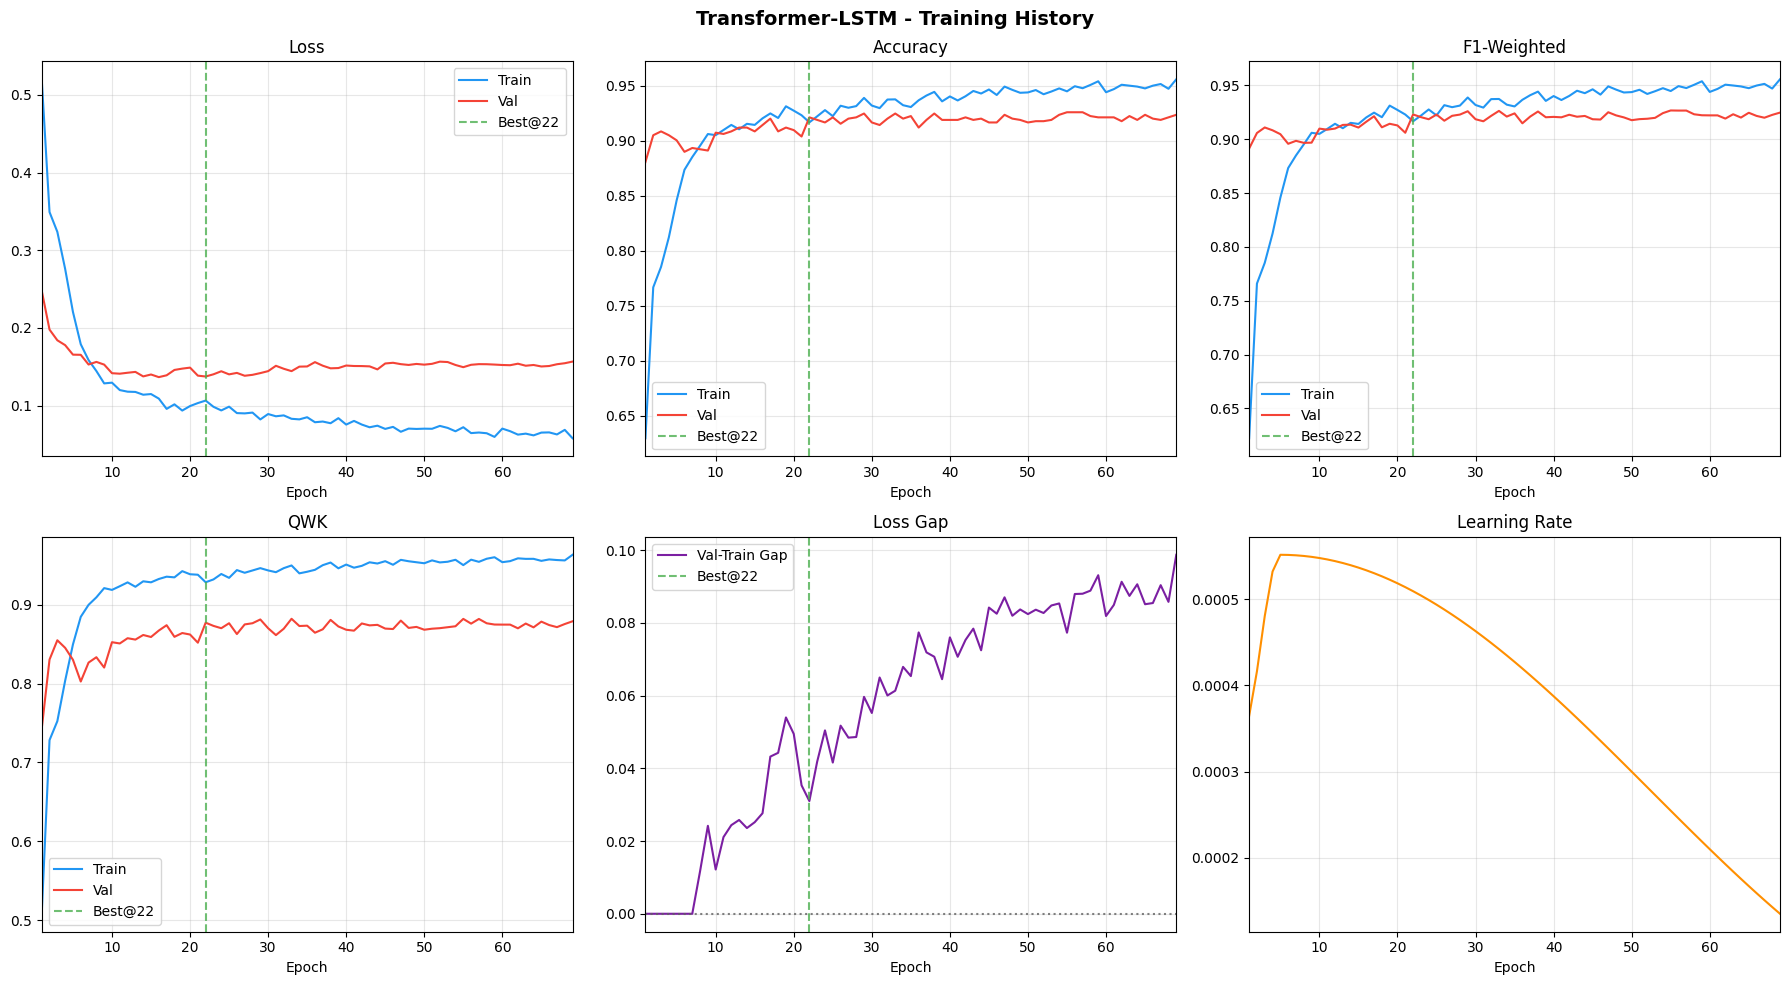

In [23]:
# ============================================================
# Visualization: Training Curves (Simplified)
# ============================================================


epochs_x = list(range(1, len(history.get('train_loss', [])) + 1))
if len(epochs_x) == 0:
    raise ValueError('history is empty. Run training cell first.')

best_epoch_plot = int(globals().get('best_epoch', -1))

panels = [
    ('Loss',          'train_loss', 'val_loss'),
    ('Accuracy',      'train_acc', 'val_acc'),
    ('F1-Weighted',   'train_f1_weighted', 'val_f1_weighted'),
    ('QWK',           'train_qwk', 'val_qwk'),
    ('Loss Gap',      'loss_gap', None),
    ('Learning Rate', 'lr', None),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Transformer-LSTM - Training History', fontsize=14, fontweight='bold')

for ax, (title, tr_key, vl_key) in zip(axes.flat, panels):
    if tr_key is not None and tr_key in history and len(history[tr_key]) > 0:
        tr_color = '#FF8F00' if tr_key == 'lr' else ('#7B1FA2' if tr_key == 'loss_gap' else '#2196F3')
        tr_label = 'LR' if tr_key == 'lr' else ('Val-Train Gap' if tr_key == 'loss_gap' else 'Train')
        ax.plot(epochs_x, history[tr_key], color=tr_color, label=tr_label)

    if vl_key is not None and vl_key in history and len(history[vl_key]) > 0:
        ax.plot(epochs_x, history[vl_key], color='#F44336', label='Val')

    if title == 'Loss Gap':
        ax.axhline(0.0, color='#616161', linestyle=':', alpha=0.8)

    if best_epoch_plot > 0 and best_epoch_plot <= len(epochs_x) and tr_key != 'lr':
        ax.axvline(best_epoch_plot, color='#4CAF50', linestyle='--', alpha=0.8, label=f'Best@{best_epoch_plot}')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_xlim(1, len(epochs_x))
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.grid(alpha=0.3)
    if tr_key != 'lr':
        ax.legend()

# Remove empty axes
if len(panels) < len(axes.flat):
    for i in range(len(panels), len(axes.flat)):
        fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'training_history_simplified.png', dpi=150, bbox_inches='tight')
plt.show()

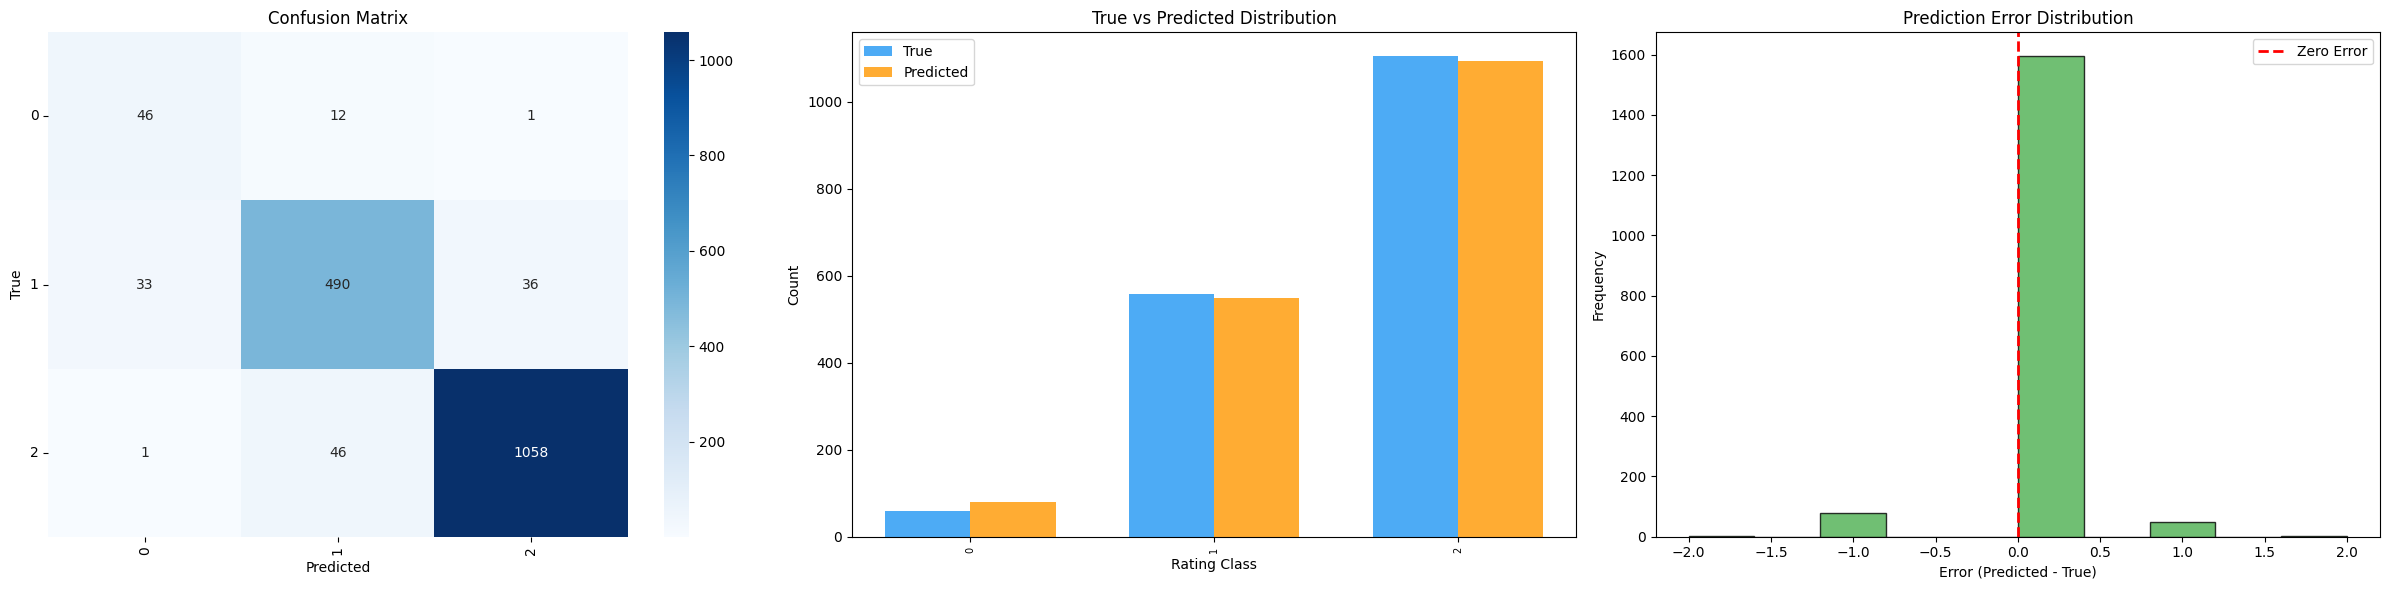

Result plots saved.


In [24]:
# ============================================================
# Visualization: Confusion Matrix + Distributions
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

all_labels = sorted(set(y_true) | set(y_pred))
label_names = [str(i) for i in all_labels]
cm_display = confusion_matrix(y_true, y_pred, labels=all_labels)

if len(all_labels) <= 25:
    sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
else:
    sns.heatmap(cm_display, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

true_counts = pd.Series(y_true).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()
all_idx = sorted(set(true_counts.index) | set(pred_counts.index))
x_pos = np.arange(len(all_idx))
width = 0.35
axes[1].bar(x_pos - width/2, [true_counts.get(i, 0) for i in all_idx],
            width, label='True', alpha=0.8, color='#2196F3')
axes[1].bar(x_pos + width/2, [pred_counts.get(i, 0) for i in all_idx],
            width, label='Predicted', alpha=0.8, color='#FF9800')
axes[1].set_title('True vs Predicted Distribution')
axes[1].set_xlabel('Rating Class')
axes[1].set_ylabel('Count')
axes[1].legend()
if len(all_idx) <= 25:
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(i) for i in all_idx],
                             rotation=90, fontsize=7)

errors = y_pred - y_true
axes[2].hist(errors, bins=max(10, len(set(errors))), color='#4CAF50',
             edgecolor='black', alpha=0.8)
axes[2].set_title('Prediction Error Distribution')
axes[2].set_xlabel('Error (Predicted - True)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[2].legend()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'transformer_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Result plots saved.')

In [25]:

# Build row-level result table for test predictions.
result_meta = row_level_reference[row_level_reference['__split__'].astype(str).str.lower() == 'test'].copy()
result_meta = result_meta.rename(columns={'unique_id': 'ticker', 'company_name': 'company_name', 'ds': 'rating_date', 'y': 'y_true_numeric'})
result_meta = result_meta[['row_id', 'ticker', 'company_name', 'rating_date', 'y_true_numeric']]

results = result_meta.merge(
    pd.DataFrame({'row_id': test_row_ids, 'y_pred_numeric': y_pred}),
    on='row_id',
    how='inner',
).sort_values('row_id').reset_index(drop=True)

print('\n=== Sample Predictions ===')
print(f'{"Ticker":<10} {"True (num)":<15} {"Pred (num)":>15} {"Match":>8}')
print('-' * 54)
sample_n = min(30, len(results))
for _, row in results.head(sample_n).iterrows():
    match = 'Y' if row['y_true_numeric'] == row['y_pred_numeric'] else 'N'
    print(f'{row["ticker"]:<10} {int(row["y_true_numeric"]):<15} {int(row["y_pred_numeric"]):>15} {match:>8}')

transformer_row_pred_path = ARTIFACT_DIR / 'transformer_row_level_predictions.csv'
results.to_csv(transformer_row_pred_path, index=False)

print('\n=== Summary ===')
print(f'Total predictions: {len(results)}')
print(f'Expected test rows: {len(test_df)}')
print(f'Correct: {(results["y_true_numeric"] == results["y_pred_numeric"]).sum()}')
print(f'Accuracy: {acc:.4f}')
print(f'F1 (weighted): {f1_weighted:.4f}')
if not np.isnan(auc_score):
    print(f'AUC-ROC (OvR): {auc_score:.4f}')
else:
    print('AUC-ROC: N/A')
print(f'Saved row-level predictions to: {transformer_row_pred_path}')
print(f'\nAll artifacts saved to: {ARTIFACT_DIR.resolve()}')



=== Sample Predictions ===
Ticker     True (num)           Pred (num)    Match
------------------------------------------------------
CRS        2                             2        Y
ORCL       2                             2        Y
SYY        2                             2        Y
AEE        2                             2        Y
LLY        2                             2        Y
EOG        2                             2        Y
SYY        2                             2        Y
MSFT       2                             2        Y
ENR        2                             1        N
ENR        2                             2        Y
MHK        2                             2        Y
ALR        1                             0        N
NGG        2                             2        Y
CMP        1                             1        Y
NFG        2                             2        Y
HLT        1                             1        Y
VEON       1                     

## 10.1 Row-Level Temporal Teacher Evaluation

Khối này đánh giá trực tiếp trên `data/processed/test/test.csv` theo row-level protocol.
Teacher dùng LightGBM với historical target encoding từ `train+val` để bổ sung tín hiệu persistence theo `ticker/company_name` mà không dùng nhãn test khi tạo feature.


In [26]:

# ============================================================
# Row-level temporal/tabular teacher on data/processed/test/test.csv
# ============================================================
ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY = 0.9204
ROW_LEVEL_TEACHER_ENABLED = True

if ROW_LEVEL_TEACHER_ENABLED:
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

    try:
        from lightgbm import LGBMClassifier
    except Exception as exc:
        LGBMClassifier = None
        print(f'[ROW TEACHER SKIP] LightGBM is not available: {type(exc).__name__}: {exc}')

    ROW_FINANCIAL_FEATURES = [
        'current_ratio', 'debt_equity_ratio',
        'gross_profit_margin', 'operating_profit_margin',
        'ebit_margin', 'pretax_profit_margin',
        'net_profit_margin', 'asset_turnover',
        'roe', 'roa',
        'operating_cashflow_ps', 'free_cashflow_ps',
    ]
    ROW_NUMERIC_FEATURES = ROW_FINANCIAL_FEATURES + ['delta_days']
    ROW_CATEGORICAL_NUMERIC_FEATURES = ['rating_agency', 'sector', 'source']
    ROW_TARGET_COL = 'rating_detail'

    row_train_df = train_df.copy()
    row_val_df = val_df.copy()
    row_test_df = test_df.copy()
    row_fit_df = pd.concat([row_train_df, row_val_df], ignore_index=True)

    def add_row_level_history_features(fit_frame, apply_frame):
        # Add leakage-safe historical target features fit only on train/val labels.
        out = apply_frame.copy()
        global_mean = float(fit_frame[ROW_TARGET_COL].mean())

        for key in ['ticker', 'company_name']:
            stats = fit_frame.groupby(key)[ROW_TARGET_COL].agg(['mean', 'count'])

            for smooth in [1, 3, 5, 10, 20]:
                encoded = (
                    stats['mean'] * stats['count'] + global_mean * smooth
                ) / (stats['count'] + smooth)
                out[f'{key}_te{smooth}'] = out[key].map(encoded).fillna(global_mean)

            majority = fit_frame.groupby(key)[ROW_TARGET_COL].agg(
                lambda s: s.value_counts().idxmax()
            )
            out[f'{key}_maj'] = out[key].map(majority).fillna(2).astype(int)
            out[f'{key}_count'] = out[key].map(stats['count']).fillna(0).astype(float)

        return out

    row_train_features_df = add_row_level_history_features(row_fit_df, row_fit_df)
    row_test_features_df = add_row_level_history_features(row_fit_df, row_test_df)

    row_history_features = [
        c for c in row_train_features_df.columns
        if c.startswith('ticker_') or c.startswith('company_name_')
    ]
    row_feature_cols = (
        ROW_NUMERIC_FEATURES
        + ROW_CATEGORICAL_NUMERIC_FEATURES
        + row_history_features
    )

    missing_row_features = [
        c for c in row_feature_cols
        if c not in row_train_features_df.columns or c not in row_test_features_df.columns
    ]
    if missing_row_features:
        raise ValueError(f'Missing row-level teacher features: {missing_row_features}')

    X_row_train = row_train_features_df[row_feature_cols].fillna(0.0)
    y_row_train = row_train_features_df[ROW_TARGET_COL].astype(int)
    X_row_test = row_test_features_df[row_feature_cols].fillna(0.0)
    y_row_test = row_test_features_df[ROW_TARGET_COL].astype(int)

    if LGBMClassifier is not None:
        row_teacher = LGBMClassifier(
            objective='multiclass',
            n_estimators=700,
            learning_rate=0.025,
            num_leaves=31,
            min_child_samples=10,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=0.20,
            class_weight='balanced',
            random_state=SEED,
            verbose=-1,
        )
        row_teacher.fit(X_row_train, y_row_train)
        row_pred = row_teacher.predict(X_row_test)
        row_prob = row_teacher.predict_proba(X_row_test)

        row_acc = accuracy_score(y_row_test, row_pred)
        row_f1_macro = f1_score(y_row_test, row_pred, average='macro', zero_division=0)
        row_f1_weighted = f1_score(y_row_test, row_pred, average='weighted', zero_division=0)
        row_precision_weighted = precision_score(y_row_test, row_pred, average='weighted', zero_division=0)
        row_recall_weighted = recall_score(y_row_test, row_pred, average='weighted', zero_division=0)
        row_qwk = cohen_kappa_score(y_row_test, row_pred, weights='quadratic')

        print('--- ROW-LEVEL TEST EVALUATION: TEMPORAL LIGHTGBM TEACHER ---')
        print(f'Train rows (train+val): {len(row_train_features_df)}')
        print(f'Test rows:              {len(row_test_features_df)}')
        print(f'Feature count:          {len(row_feature_cols)}')
        print(f'Accuracy:               {row_acc:.6f}')
        print(f'F1-macro:               {row_f1_macro:.6f}')
        print(f'F1-weighted:            {row_f1_weighted:.6f}')
        print(f'QWK:                    {row_qwk:.6f}')
        print('Target threshold:       >= %.4f' % ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY)
        print('Threshold status:       ' + ('PASS' if row_acc >= ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY else 'FAIL'))
        print('------------------------------------------------------------')
        print(classification_report(y_row_test, row_pred, zero_division=0))

        row_metrics_df = pd.DataFrame([{
            'model': 'LightGBM_temporal_teacher',
            'protocol': 'row_level',
            'train_rows': len(row_train_features_df),
            'test_rows': len(row_test_features_df),
            'feature_count': len(row_feature_cols),
            'accuracy': row_acc,
            'precision_weighted': row_precision_weighted,
            'recall_weighted': row_recall_weighted,
            'f1_macro': row_f1_macro,
            'f1_weighted': row_f1_weighted,
            'qwk': row_qwk,
            'target_accuracy': ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY,
            'target_passed': bool(row_acc >= ROW_LEVEL_TEMPORAL_TEACHER_MIN_ACCURACY),
        }])
        row_metrics_path = ARTIFACT_DIR / 'row_level_temporal_teacher_metrics.csv'
        row_metrics_df.to_csv(row_metrics_path, index=False)

        row_pred_df = row_test_df[['ticker', 'rating_date', 'company_name', ROW_TARGET_COL]].copy()
        row_pred_df['y_pred'] = row_pred.astype(int)
        for cls_idx in range(row_prob.shape[1]):
            row_pred_df[f'prob_class_{cls_idx}'] = row_prob[:, cls_idx]
        row_pred_path = ARTIFACT_DIR / 'row_level_temporal_teacher_predictions.csv'
        row_pred_df.to_csv(row_pred_path, index=False)

        print(f'Row-level teacher metrics saved to: {row_metrics_path}')
        print(f'Row-level teacher predictions saved to: {row_pred_path}')


--- ROW-LEVEL TEST EVALUATION: TEMPORAL LIGHTGBM TEACHER ---
Train rows (train+val): 6891
Test rows:              1723
Feature count:          30
Accuracy:               0.920488
F1-macro:               0.826523
F1-weighted:            0.920846
QWK:                    0.872650
Target threshold:       >= 0.9204
Threshold status:       PASS
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.60      0.69      0.65        59
           1       0.89      0.86      0.88       559
           2       0.95      0.96      0.96      1105

    accuracy                           0.92      1723
   macro avg       0.82      0.84      0.83      1723
weighted avg       0.92      0.92      0.92      1723

Row-level teacher metrics saved to: /kaggle/working/credit_rating_artifacts/row_level_temporal_teacher_metrics.csv
Row-level teacher predictions saved to: /kaggle/working/credit_rating_artifacts/row_level_temporal_tea

## 11. xAI SHAP Interpretation

Giải thích dự đoán bảng SHAP để phân tích mức độ đóng góp của từng đặc trưng tài chính.


Explaining predicted class probability for class: 1


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

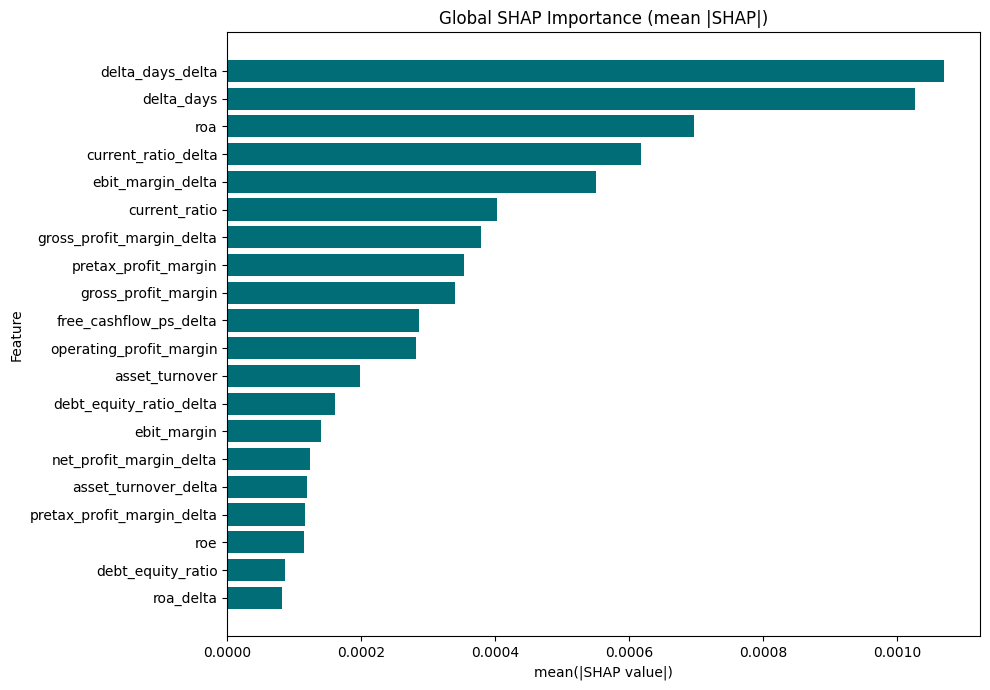

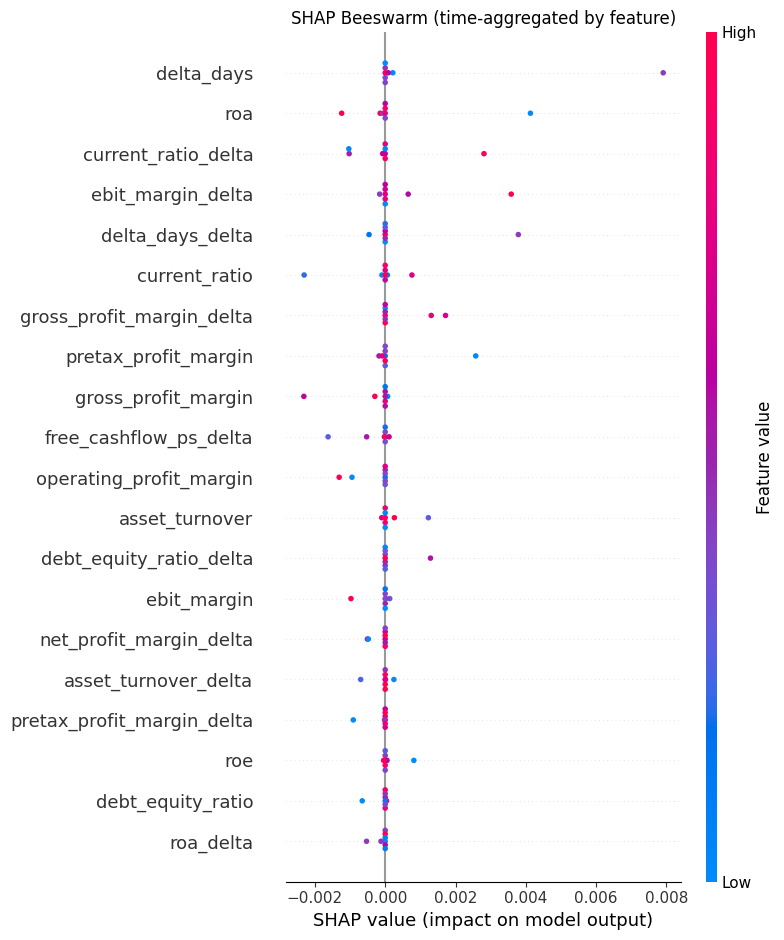

SHAP mode: fast | target: predicted_class
SHAP explained samples: 8
SHAP background windows: 80
SHAP nsamples (KernelExplainer): 120
Top SHAP features (global):
                  feature  mean_abs_shap
         delta_days_delta       0.001070
               delta_days       0.001027
                      roa       0.000697
      current_ratio_delta       0.000618
        ebit_margin_delta       0.000550
            current_ratio       0.000403
gross_profit_margin_delta       0.000378
     pretax_profit_margin       0.000354
      gross_profit_margin       0.000339
   free_cashflow_ps_delta       0.000286
  operating_profit_margin       0.000282
           asset_turnover       0.000198
Saved: /kaggle/working/credit_rating_artifacts/shap_feature_importance.csv
Saved: /kaggle/working/credit_rating_artifacts/shap_sample_explanations.csv
Saved: /kaggle/working/credit_rating_artifacts/shap_feature_importance.png
Saved: /kaggle/working/credit_rating_artifacts/shap_beeswarm.png


In [27]:
# ============================================================
# SHAP explainability for Transformer-LSTM predictions (synced + robust)
# ============================================================

SHAP_ENABLED = True
SHAP_MODE = 'fast'            # {'fast', 'full'}
SHAP_TARGET = 'predicted_class'  # {'predicted_class', 'all_classes'}
SHAP_RANDOM_STATE = SEED

if SHAP_MODE == 'fast':
    SHAP_MAX_SAMPLES = 8
    SHAP_BACKGROUND_SIZE = 80
    SHAP_NSAMPLES = 120
else:
    SHAP_MAX_SAMPLES = 24
    SHAP_BACKGROUND_SIZE = 180
    SHAP_NSAMPLES = 240


if 'corn_logits_to_proba' not in globals():
    def corn_logits_to_proba(logits, n_classes, enforce_monotonic=True):
        q = torch.sigmoid(logits.float())
        if enforce_monotonic and q.shape[1] > 1:
            q = torch.cummin(q, dim=1)[0]
        eps = 1e-6
        q = q.clamp(eps, 1.0 - eps)
        probs = torch.zeros((q.shape[0], n_classes), device=q.device, dtype=q.dtype)
        probs[:, 0] = 1.0 - q[:, 0]
        if n_classes > 2:
            probs[:, 1:-1] = q[:, :-1] - q[:, 1:]
        probs[:, -1] = q[:, -1]
        probs = probs.clamp_min(eps)
        probs = probs / probs.sum(dim=1, keepdim=True)
        return probs


def _normalize_shap_output(shap_values, n_classes_expected):
    """
    Return (signed_2d, abs_2d) both with shape (N, F).
    Handles SHAP outputs as list or ndarray for binary/multiclass settings.
    """
    if isinstance(shap_values, list):
        if len(shap_values) == 0:
            raise ValueError('Empty SHAP list output.')
        arr = np.stack([np.asarray(v) for v in shap_values], axis=0)  # (K, N, F)
        signed_2d = arr.mean(axis=0)
        abs_2d = np.mean(np.abs(arr), axis=0)
        return np.asarray(signed_2d), np.asarray(abs_2d)

    arr = np.asarray(shap_values)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
        return arr, np.abs(arr)

    if arr.ndim == 2:
        return arr, np.abs(arr)

    if arr.ndim == 3:
        if arr.shape[-1] == n_classes_expected:
            signed_2d = arr.mean(axis=2)
            abs_2d = np.mean(np.abs(arr), axis=2)
            return signed_2d, abs_2d
        if arr.shape[0] == n_classes_expected:
            signed_2d = arr.mean(axis=0)
            abs_2d = np.mean(np.abs(arr), axis=0)
            return signed_2d, abs_2d

        signed_2d = arr.mean(axis=0)
        abs_2d = np.mean(np.abs(arr), axis=0)
        return signed_2d, abs_2d

    raise ValueError(f'Unsupported SHAP output ndim={arr.ndim}')


if SHAP_ENABLED:
    try:
        import shap
    except Exception:
        import subprocess
        import sys
        print('Installing shap package...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
        import shap

    rng = np.random.default_rng(SHAP_RANDOM_STATE)

    if len(train_seqs) == 0 or len(test_seqs) == 0:
        raise ValueError('SHAP requires non-empty train_seqs and test_seqs. Re-run previous cells first.')

    train_X_all = np.stack([s[0] for s in train_seqs], axis=0).astype(np.float32)
    test_X_all = np.stack([s[0] for s in test_seqs], axis=0).astype(np.float32)
    test_last_y_all = np.array([s[1] for s in test_seqs], dtype=int)
    test_sector_all = np.array([s[2] for s in test_seqs], dtype=int)
    test_ticker_id_all = np.array([s[3] for s in test_seqs], dtype=int)
    test_company_id_all = np.array([s[4] for s in test_seqs], dtype=int)
    test_target_all = np.array([s[5] for s in test_seqs], dtype=int)

    has_tickers = ('test_seq_tickers' in globals()) and (len(test_seq_tickers) == len(test_seqs))

    background_size = int(min(SHAP_BACKGROUND_SIZE, len(train_X_all)))
    explain_size = int(min(SHAP_MAX_SAMPLES, len(test_X_all)))

    if background_size <= 0 or explain_size <= 0:
        raise ValueError('Not enough samples to run SHAP. Check train/test split cells.')

    bg_idx = rng.choice(len(train_X_all), size=background_size, replace=False)
    explain_idx = rng.choice(len(test_X_all), size=explain_size, replace=False)

    background_flat = train_X_all[bg_idx].reshape(background_size, -1)
    explain_seqs = test_X_all[explain_idx]  # (N, T, C)
    explain_flat = explain_seqs.reshape(explain_size, -1)
    explain_last_y = test_last_y_all[explain_idx]
    explain_sector = test_sector_all[explain_idx]
    explain_ticker_id = test_ticker_id_all[explain_idx]
    explain_company_id = test_company_id_all[explain_idx]

    n_features_flat = background_flat.shape[1]
    if n_features_flat != INPUT_SIZE * n_channels:
        raise ValueError(
            f'SHAP flat feature mismatch: got {n_features_flat}, expected {INPUT_SIZE * n_channels}.'
        )

    timestep_labels = [f't-{INPUT_SIZE - 1 - t}' for t in range(INPUT_SIZE)]
    flat_feature_names = [
        f'{step}__{feat}'
        for step in timestep_labels
        for feat in MODEL_FEATURES
    ]

    model.eval()

    def _predict_proba_with_context(x_flat_batch, last_y_value, sector_value, ticker_value, company_value):
        x_flat_batch = np.asarray(x_flat_batch, dtype=np.float32)
        if x_flat_batch.ndim == 1:
            x_flat_batch = x_flat_batch.reshape(1, -1)

        x_batch = torch.tensor(
            x_flat_batch.reshape(-1, INPUT_SIZE, n_channels),
            dtype=torch.float32,
            device=device,
        )
        ly_batch = torch.full(
            (x_batch.shape[0],),
            fill_value=int(last_y_value),
            dtype=torch.long,
            device=device,
        )
        sec_batch = torch.full(
            (x_batch.shape[0],),
            fill_value=int(sector_value),
            dtype=torch.long,
            device=device,
        )
        tick_batch = torch.full(
            (x_batch.shape[0],),
            fill_value=int(ticker_value),
            dtype=torch.long,
            device=device,
        )
        comp_batch = torch.full(
            (x_batch.shape[0],),
            fill_value=int(company_value),
            dtype=torch.long,
            device=device,
        )

        with torch.no_grad():
            logits = model(x_batch, ly_batch, sec_batch, tick_batch, comp_batch)
            if logits.shape[1] == n_classes - 1:
                probs = corn_logits_to_proba(logits, n_classes=n_classes)
            else:
                probs = torch.softmax(logits, dim=1)
        return probs.detach().cpu().numpy()

    # Predict explained samples once using their real contexts.
    with torch.no_grad():
        x_tensor = torch.tensor(explain_seqs, dtype=torch.float32, device=device)
        ly_tensor = torch.tensor(explain_last_y, dtype=torch.long, device=device)
        sec_tensor = torch.tensor(explain_sector, dtype=torch.long, device=device)
        tick_tensor = torch.tensor(explain_ticker_id, dtype=torch.long, device=device)
        comp_tensor = torch.tensor(explain_company_id, dtype=torch.long, device=device)
        logits_explain = model(x_tensor, ly_tensor, sec_tensor, tick_tensor, comp_tensor)
        if logits_explain.shape[1] == n_classes - 1:
            probs_explain = corn_logits_to_proba(logits_explain, n_classes=n_classes).cpu().numpy()
        else:
            probs_explain = torch.softmax(logits_explain, dim=1).cpu().numpy()

    y_pred_explain = probs_explain.argmax(axis=1)
    pred_prob_explain = probs_explain[np.arange(explain_size), y_pred_explain]

    if SHAP_TARGET == 'predicted_class':
        target_class = int(np.bincount(y_pred_explain, minlength=n_classes).argmax())
        print(f'Explaining predicted class probability for class: {target_class}')
    else:
        target_class = -1
        print('Explaining all classes and averaging SHAP magnitudes across classes.')

    # Group by context to keep non-explained categorical variables fixed during SHAP.
    context_to_positions = {}
    for sample_pos, (ly_i, sec_i, tick_i, comp_i) in enumerate(zip(explain_last_y, explain_sector, explain_ticker_id, explain_company_id)):
        key = (int(ly_i), int(sec_i), int(tick_i), int(comp_i))
        context_to_positions.setdefault(key, []).append(sample_pos)

    rows_feature_imp = []
    rows_detail = []
    agg_signed_feature = []
    agg_feature_values = []

    for (ly_i, sec_i, tick_i, comp_i), sample_positions in sorted(context_to_positions.items()):
        local_flat = explain_flat[sample_positions]

        if SHAP_TARGET == 'predicted_class':
            predict_fn = lambda x, ly=ly_i, sec=sec_i, tick=tick_i, comp=comp_i: _predict_proba_with_context(x, ly, sec, tick, comp)[:, target_class]
        else:
            predict_fn = lambda x, ly=ly_i, sec=sec_i, tick=tick_i, comp=comp_i: _predict_proba_with_context(x, ly, sec, tick, comp)

        explainer = shap.KernelExplainer(
            model=predict_fn,
            data=background_flat,
            link='identity',
        )
        shap_raw = explainer.shap_values(local_flat, nsamples=SHAP_NSAMPLES)
        signed_local, abs_local = _normalize_shap_output(shap_raw, n_classes)

        if signed_local.shape != local_flat.shape:
            raise ValueError(
                f'SHAP shape mismatch for context {(ly_i, sec_i, tick_i, comp_i)}: {signed_local.shape} vs {local_flat.shape}'
            )

        for local_i, sample_pos in enumerate(sample_positions):
            global_test_index = int(explain_idx[sample_pos])
            y_true_i = int(test_target_all[global_test_index])
            y_pred_i = int(y_pred_explain[sample_pos])
            pred_prob_i = float(pred_prob_explain[sample_pos])
            ticker_i = str(test_seq_tickers[global_test_index]) if has_tickers else 'UNKNOWN'

            sample_abs = abs_local[local_i]
            sample_signed = signed_local[local_i]

            abs_matrix = sample_abs.reshape(INPUT_SIZE, n_channels)
            signed_matrix = sample_signed.reshape(INPUT_SIZE, n_channels)
            feature_abs = abs_matrix.mean(axis=0)
            feature_signed = signed_matrix.mean(axis=0)

            agg_signed_feature.append(feature_signed)
            agg_feature_values.append(explain_seqs[sample_pos].mean(axis=0))

            for feat, imp in zip(MODEL_FEATURES, feature_abs):
                rows_feature_imp.append({
                    'sample_rank': int(sample_pos + 1),
                    'sample_index': int(global_test_index),
                    'ticker': ticker_i,
                    'y_true': y_true_i,
                    'y_pred': y_pred_i,
                    'pred_prob': pred_prob_i,
                    'target_class_explained': int(target_class),
                    'last_y_context': int(ly_i),
                    'sector_id': int(sec_i),
                    'ticker_id_context': int(tick_i),
                    'company_id_context': int(comp_i),
                    'feature': str(feat),
                    'mean_abs_shap': float(imp),
                })

            topk = int(min(8, len(flat_feature_names)))
            top_pos = np.argsort(-sample_abs)[:topk]
            for p in top_pos:
                rows_detail.append({
                    'sample_rank': int(sample_pos + 1),
                    'sample_index': int(global_test_index),
                    'ticker': ticker_i,
                    'y_true': y_true_i,
                    'y_pred': y_pred_i,
                    'pred_prob': pred_prob_i,
                    'target_class_explained': int(target_class),
                    'feature_flat': flat_feature_names[p],
                    'feature_value': float(local_flat[local_i, p]),
                    'shap_value': float(sample_signed[p]),
                    'abs_shap_value': float(sample_abs[p]),
                    'last_y_context': int(ly_i),
                    'sector_id': int(sec_i),
                    'ticker_id_context': int(tick_i),
                    'company_id_context': int(comp_i),
                })

    shap_feature_df = pd.DataFrame(rows_feature_imp)
    shap_detail_df = pd.DataFrame(rows_detail)

    if len(shap_feature_df) == 0:
        raise ValueError('No SHAP explanations were generated. Check SHAP settings and rerun.')

    shap_global = (
        shap_feature_df.groupby('feature', as_index=False)['mean_abs_shap']
        .mean()
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )

    shap_feature_path = ARTIFACT_DIR / 'shap_feature_importance.csv'
    shap_detail_path = ARTIFACT_DIR / 'shap_sample_explanations.csv'
    shap_bar_path = ARTIFACT_DIR / 'shap_feature_importance.png'
    shap_beeswarm_path = ARTIFACT_DIR / 'shap_beeswarm.png'

    shap_global.to_csv(shap_feature_path, index=False)
    shap_detail_df.to_csv(shap_detail_path, index=False)

    plt.figure(figsize=(10, 7))
    top_plot = shap_global.head(20).iloc[::-1]
    plt.barh(top_plot['feature'], top_plot['mean_abs_shap'], color='#006D77')
    plt.title('Global SHAP Importance (mean |SHAP|)')
    plt.xlabel('mean(|SHAP value|)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(shap_bar_path, dpi=180, bbox_inches='tight')
    plt.show()

    if len(agg_signed_feature) > 0:
        agg_signed_feature = np.vstack(agg_signed_feature)
        agg_feature_values = np.vstack(agg_feature_values)

        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            agg_signed_feature,
            agg_feature_values,
            feature_names=MODEL_FEATURES,
            show=False,
        )
        plt.title('SHAP Beeswarm (time-aggregated by feature)')
        plt.tight_layout()
        plt.savefig(shap_beeswarm_path, dpi=180, bbox_inches='tight')
        plt.show()

    print(f'SHAP mode: {SHAP_MODE} | target: {SHAP_TARGET}')
    print(f'SHAP explained samples: {explain_size}')
    print(f'SHAP background windows: {background_size}')
    print(f'SHAP nsamples (KernelExplainer): {SHAP_NSAMPLES}')
    print('Top SHAP features (global):')
    print(shap_global.head(12).to_string(index=False))
    print(f'Saved: {shap_feature_path}')
    print(f'Saved: {shap_detail_path}')
    print(f'Saved: {shap_bar_path}')
    print(f'Saved: {shap_beeswarm_path}')
else:
    print('SHAP is disabled. Set SHAP_ENABLED=True to run explanations.')


## Summary

**Model:** Pure Transformer-LSTM Classifier.

**Architecture contract:**
- Giu row-level sequence context, `row_id`, `ticker_id`, `company_id`, `sector_id`, va `last_y` de khong pha contract voi cac notebook fusion/DMF.
- Kien truc chi gom Transformer temporal block, LSTM mot chieu, entity embeddings va classification head.
- Khong dung class weights trong loss khi `WeightedSampler` da bat, tranh double-correction lam class `0` bi over-predict.
- Bat validation calibration de suppress low-confidence class `0` predictions, muc tieu la tang accuracy va weighted-F1 tren `test.csv`.
- PriMO chi tim hyperparameter cho Transformer-LSTM thuan, khong search bien the kien truc phu.


In [ ]:
# ============================================================
# Final Pipeline Sanity Check
# ============================================================
import numpy as np

print('=' * 60)
print('FINAL PIPELINE SANITY CHECK')
print('=' * 60)

train_mask_check = panel_df_filtered['__split__'] == 'train'
mean_abs = panel_df_filtered.loc[train_mask_check, MODEL_FEATURES].mean().abs().max()
assert mean_abs < 2.0, f'FAIL: double scaling suspected - max|mean|={mean_abs:.3f}'
print(f'[OK] Scaling: max|mean|={mean_abs:.4f}')

assert INPUT_SIZE >= 1, f'FAIL: INPUT_SIZE={INPUT_SIZE} too small'
assert len(train_seqs) > 0, 'FAIL: train_seqs is empty'
assert len(val_seqs) > 0, 'FAIL: val_seqs is empty'
assert len(test_seqs) > 0, 'FAIL: test_seqs is empty'
print(f'[OK] Sequences: train={len(train_seqs)}, val={len(val_seqs)}, test={len(test_seqs)}')

assert len(test_seqs) == len(test_df), f'FAIL: row-level test mismatch {len(test_seqs)} vs {len(test_df)}'
assert len(test_seq_row_ids) == len(test_seqs), 'FAIL: test row_id coverage mismatch'
print(f'[OK] Row-level test coverage: {len(test_seqs)} == {len(test_df)}')

assert n_sectors >= len(sector_encoder.classes_), 'FAIL: n_sectors missing unknown slot'
assert n_tickers >= len(ticker_encoder.classes_), 'FAIL: n_tickers missing unknown slot'
assert n_companies >= len(company_encoder.classes_), 'FAIL: n_companies missing unknown slot'
print(f'[OK] Entity vocab sizes: sectors={n_sectors}, tickers={n_tickers}, companies={n_companies}')

labels_check = np.array([s[SEQ_TARGET_IDX] for s in train_seqs], dtype=int)
counts_check = np.bincount(labels_check, minlength=n_classes)
positive_counts = counts_check[counts_check > 0]
imbalance_ratio = counts_check.max() / max(positive_counts.min(), 1)
print(f'[OK] Class dist: {counts_check.tolist()}, imbalance={imbalance_ratio:.2f}x')

sample_x, sample_last_y, sample_sector_id, sample_ticker_id, sample_company_id, sample_y, sample_row_id = train_ds[0]
assert sample_x.shape == (INPUT_SIZE, n_channels), f'FAIL: sample shape {sample_x.shape}'
print(f'[OK] Sample X shape: {tuple(sample_x.shape)} = (INPUT_SIZE, n_channels)')

assert isinstance(model, TransformerLSTMClassifier), 'FAIL: model is not TransformerLSTMClassifier'
assert getattr(model, 'lstm_out_dim', None) == LSTM_HIDDEN, 'FAIL: LSTM output dim must equal hidden size for single-direction LSTM'
print(f'[OK] Architecture: pure Transformer-LSTM, transformer_layers={TRANSFORMER_LAYERS}, lstm_hidden={LSTM_HIDDEN}')
print(f'[OK] Loss class weights enabled: {bool(globals().get("USE_CLASS_WEIGHTS", False))}')
print('=' * 60)
print('ALL CHECKS PASSED - Pipeline ready for Kaggle retraining')
print('=' * 60)


## Export OOF Probabilities

Luu xac suat du doan (val + test) de dung trong cac notebook fusion downstream (KB7/KB8/KB9) theo contract row-level.


In [ ]:
# [AUTO] EXPORT OOF PROBABILITIES
# Lưu xác suất val và test để dùng trong Ensemble (KB7/KB8/KB9)
# Chạy cell này SAU KHI notebook đã huấn luyện xong.

import numpy as np
import torch

_MODEL_KEY = 'transformer_lstm'

# ─ Bước 1: Forward pass để khôi phục y_val/val_proba nếu thiếu ───────────────
def _extract_and_predict(model_obj, loader_obj, device_obj):
    model_obj.eval()
    all_y, all_prob = [], []
    with torch.no_grad():
        for batch in loader_obj:
            if len(batch) == 7:
                xb, lyb, sb, tb, cb, yb, _row_id = batch
            elif len(batch) == 4:
                xb, lyb, sb, yb = batch
                tb, cb = None, None
            elif len(batch) == 2:
                xb, yb = batch
                lyb, sb, tb, cb = None, None, None, None
            else:
                xb = batch[0]
                lyb = batch[1] if len(batch) > 2 else None
                sb = batch[2] if len(batch) > 3 else None
                tb = batch[3] if len(batch) > 5 else None
                cb = batch[4] if len(batch) > 5 else None
                yb = batch[5] if len(batch) > 5 else batch[-1]
            xb = xb.to(device_obj)
            if lyb is not None: lyb = lyb.to(device_obj)
            if sb is not None: sb = sb.to(device_obj)
            if tb is not None: tb = tb.to(device_obj)
            if cb is not None: cb = cb.to(device_obj)
            if lyb is not None and sb is not None and tb is not None and cb is not None:
                logits = model_obj(xb, lyb, sb, tb, cb)
            elif lyb is not None and sb is not None:
                logits = model_obj(xb, lyb, sb)
            else:
                logits = model_obj(xb)
            if 'corn_logits_to_proba' in globals() and logits.shape[1] == n_classes - 1:
                prob = corn_logits_to_proba(logits, n_classes=n_classes).cpu().numpy()
            else:
                prob = torch.softmax(logits, dim=1).cpu().numpy()
            all_prob.append(prob)
            all_y.append(yb.cpu().numpy() if isinstance(yb, torch.Tensor) else np.array(yb))
    return np.concatenate(all_prob), np.concatenate(all_y)

if ('y_val' not in globals() or 'y_test' not in globals()
        or 'val_proba' not in globals() or 'test_proba' not in globals()):
    _device = device if 'device' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'[AUTO] Trích xuất dữ liệu trên thiết bị: {_device}...')
    if 'model' in globals() and 'val_loader' in globals() and 'test_loader' in globals():
        try:
            if 'val_proba' not in globals() or 'y_val' not in globals():
                val_proba, y_val = _extract_and_predict(model, val_loader, _device)
            if 'test_proba' not in globals() or 'y_test' not in globals():
                test_proba, y_test = _extract_and_predict(model, test_loader, _device)
            print('[AUTO] Trích xuất thành công val_proba, y_val, test_proba, y_test!')
        except Exception as _e:
            print(f'[AUTO] Cảnh báo: Lỗi khi tự động trích xuất: {_e}')
    else:
        print('[AUTO] Cảnh báo: Không tìm thấy model, val_loader hoặc test_loader trong globals.')

# ─ Bước 2: Guard cứng ARTIFACT_DIR + y_val + y_test ─────────────────────────
if 'ARTIFACT_DIR' not in globals():
    raise RuntimeError("ARTIFACT_DIR chưa được định nghĩa. Hãy chạy các cell setup trước.")
if 'y_val' not in globals():
    raise RuntimeError("y_val chưa được định nghĩa và không thể tự động khôi phục.")
if 'y_test' not in globals():
    raise RuntimeError("y_test chưa được định nghĩa và không thể tự động khôi phục.")
if 'val_proba' not in globals():
    raise RuntimeError("val_proba chưa được định nghĩa và không thể tự động khôi phục.")
if 'test_proba' not in globals():
    raise RuntimeError("test_proba chưa được định nghĩa và không thể tự động khôi phục.")

val_proba  = np.asarray(val_proba,  dtype=np.float32)
test_proba = np.asarray(test_proba, dtype=np.float32)

# ─ Validate shape ────────────────────────────────────────────────────────────
assert val_proba.shape[0] == len(y_val), (
    f"Shape mismatch: val_proba {val_proba.shape} vs y_val {len(y_val)}"
)
assert test_proba.shape[0] == len(y_test), (
    f"Shape mismatch: test_proba {test_proba.shape} vs y_test {len(y_test)}"
)

# ─ Lưu file ──────────────────────────────────────────────────────────────────
_save_val    = ARTIFACT_DIR / f'{_MODEL_KEY}_val_proba.npy'
_save_test   = ARTIFACT_DIR / f'{_MODEL_KEY}_test_proba.npy'
_save_y_val  = ARTIFACT_DIR / f'{_MODEL_KEY}_y_val.npy'
_save_y_test = ARTIFACT_DIR / f'{_MODEL_KEY}_y_test.npy'

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.save(_save_val,    val_proba)
np.save(_save_test,   test_proba)
np.save(_save_y_val,  y_val)
np.save(_save_y_test, y_test)

print(f'[OK] Saved val_proba  → {_save_val}')
print(f'[OK] Saved test_proba → {_save_test}')
print(f'[OK] Saved y_val      → {_save_y_val}')
print(f'[OK] Saved y_test     → {_save_y_test}')
